# IA Responsable, German Credit Dataset

IA708, Télécom Paris, 2026

Étudiants : Julien GIMENEZ, Hugo FANCHINI, Paul CINTRA, Yimou ZHANG, Zaher HAMADEH

### Utilisation de l'IA dans ce projet

Dans le cadre de ce projet, nous avons utilisé ponctuellement des outils d'intelligence artificielle générative, notamment des assistants conversationnels de type ChatGPT. Leur utilisation n'a pas eu vocation à remplacer le travail d'analyse, de conception ou d'expérimentation réalisé par le groupe, mais plutôt à servir de support méthodologique et technique à certaines étapes du projet.

Ces outils ont principalement été employés comme moteurs de recherche augmentés, afin d'obtenir rapidement des explications générales sur certaines notions du cours, sur les méthodes de machine learning équitable et interprétable, ou encore sur des points techniques liés à leur mise en œuvre. Les informations obtenues par ce biais ont systématiquement été confrontées aux supports de cours, aux documents fournis dans le cadre du projet, ainsi qu'aux sources scientifiques ou documentaires pertinentes lorsque cela était nécessaire. L'objectif était donc de faciliter la compréhension initiale, sans considérer les réponses générées comme des références définitives.

Les outils d'IA ont également été utilisés comme aide ponctuelle à la programmation. Ils ont pu contribuer à générer certaines portions de code simples, à proposer des structures de fonctions, à expliquer des erreurs rencontrées lors de l'exécution, ou encore à suggérer des pistes de correction pour des bugs. Cependant, le code final intégré au projet a été relu, adapté, testé et validé par les membres du groupe. Les choix méthodologiques, les expérimentations réalisées, l'interprétation des résultats et les conclusions du rapport relèvent du travail du groupe.

Enfin, ces outils ont servi d'appui pour la structuration et la rédaction du rapport. À partir du contenu, des résultats et des orientations définis au préalable par le groupe, ils ont pu aider à reformuler certaines explications, à améliorer la clarté de certains passages ou à générer une première version structurée de certaines sections. La version finale du rapport a toutefois été relue, corrigée et complétée par le groupe afin de garantir sa cohérence avec le travail effectivement réalisé.

## Sommaire et parcours

Question : peut-on construire un scoring crédit performant et équitable ?

Plan détaillé.
1. [Chargement et traduction des labels](#1.-Chargement-et-traduction-des-labels)
2. [Exploration et données sensibles](#2.-Exploration-et-donn%C3%A9es-sensibles)
   - 2.1 [Détection de proxies](#2.1-D%C3%A9tection-de-proxies)
3. [Préparation des données](#3.-Pr%C3%A9paration)
4. [Modèle baseline : régression logistique](#4.-Mod%C3%A8le-baseline-:-r%C3%A9gression-logistique)
   - 4.1 [Visualisations de performance](#4.1-Visualisations-de-performance)
   - 4.2 [Coût métier (matrice UCI)](#4.2-Co%C3%BBt-m%C3%A9tier)
5. [Métriques de performance et d'équité](#5.-M%C3%A9triques-de-performance-et-d%27%C3%A9quit%C3%A9)
   - 5.1 [Audit intersectionnel](#5.1-Audit-intersectionnel)
6. [Atténuation des biais par pré-traitement : reweighing](#6.-Att%C3%A9nuation-des-biais-par-pr%C3%A9-traitement-:-Reweighing)
7. [Atténuation des biais par post-traitement : seuils par groupe](#7.-Att%C3%A9nuation-des-biais-par-post-traitement-:-seuils-par-groupe)
8. [Comparaison des configurations](#8.-Comparaison-des-configurations)
9. [Interprétabilité : SHAP](#9.-Interpr%C3%A9tabilit%C3%A9-:-SHAP)
   - 9.1 [SHAP local : explication individuelle](#9.1-SHAP-local-:-explication-individuelle)
   - 9.2 [Comparaison SHAP avec / sans / sans+proxies](#9.2-Comparaison-SHAP-avant-vs-apr%C3%A8s-retrait)
   - 9.3 [Performance avec / sans / sans+proxies](#9.3-Performance-et-%C3%A9quit%C3%A9-:-avec-sensibles%2C-sans-sensibles%2C-sans-sensibles-ni-proxies)
10. [Quantification d'incertitude par bootstrap](#10.-Quantification-d%27incertitude-par-bootstrap)
    - 10.1 [Intervalle de prédiction sur un client unique](#10.1-Intervalle-de-pr%C3%A9diction-sur-un-client-unique)
11. [Synthèse fairness et conclusion](#11.-Synth%C3%A8se-fairness-et-conclusion)
12. [Références](#12.-R%C3%A9f%C3%A9rences)

Stack : scikit-learn, fairlearn, shap. Robustesse adversariale remplacée par bootstrap.

## 1. Chargement et traduction des labels

UCI German Credit (Hofmann 1994) contient 1000 lignes décrites par 20 attributs codés par des libellés "Axx" peu lisibles. On commence par charger le fichier brut puis on applique un mapping vers des libellés français pour rendre les analyses suivantes plus lisibles.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)
os.makedirs("outputs", exist_ok=True)

COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]

LABEL_MAP_BY_CATEGORY = {
    "checking_status": {
        "A11": "< 0 DM",
        "A12": "0 <= solde < 200 DM",
        "A13": "solde >= 200 DM (ou salaire domicilié >= 1 an)",
        "A14": "pas de compte courant",
    },
    "credit_history": {
        "A30": "aucun crédit ou tous remboursés à temps",
        "A31": "tous les crédits dans cette banque remboursés",
        "A32": "crédits existants remboursés correctement jusqu'ici",
        "A33": "retards de paiement dans le passé",
        "A34": "compte critique / autres crédits existants",
    },
    "purpose": {
        "A40": "voiture (neuve)",
        "A41": "voiture (occasion)",
        "A42": "meubles / équipement",
        "A43": "radio / télévision",
        "A44": "électroménager",
        "A45": "réparations",
        "A46": "éducation",
        "A47": "vacances (valeur indiquée comme non utilisée)",
        "A48": "reconversion",
        "A49": "business",
        "A410": "autres",
    },
    "savings_account_bonds": {
        "A61": "< 100 DM",
        "A62": "100 <= épargne < 500 DM",
        "A63": "500 <= épargne < 1000 DM",
        "A64": "épargne >= 1000 DM",
        "A65": "inconnu / pas de compte épargne",
    },
    "present_employment_since": {
        "A71": "sans emploi",
        "A72": "< 1 an",
        "A73": "1 <= ancienneté < 4 ans",
        "A74": "4 <= ancienneté < 7 ans",
        "A75": "ancienneté >= 7 ans",
    },
    "personal_status_sex": {
        "A91": "homme, divorcé/séparé",
        "A92": "femme, divorcée/séparée/mariée",
        "A93": "homme, célibataire",
        "A94": "homme, marié/veuf",
        "A95": "femme, célibataire",
    },
    "other_debtors_guarantors": {
        "A101": "aucun",
        "A102": "co-demandeur",
        "A103": "garant",
    },
    "property": {
        "A121": "immobilier",
        "A122": "épargne logement / assurance-vie",
        "A123": "voiture ou autre (hors attr. 6)",
        "A124": "inconnu / pas de propriété",
    },
    "other_installment_plans": {
        "A141": "banque",
        "A142": "magasins",
        "A143": "aucun",
    },
    "housing": {
        "A151": "locataire",
        "A152": "propriétaire",
        "A153": "hébergé gratuitement",
    },
    "job": {
        "A171": "sans emploi / non qualifié non-résident",
        "A172": "non qualifié résident",
        "A173": "employé qualifié / officiel",
        "A174": "management / indépendant / hautement qualifié",
    },
    "telephone": {
        "A191": "aucun téléphone",
        "A192": "oui, au nom du client",
    },
    "foreign_worker": {
        "A201": "oui",
        "A202": "non",
    },
}

raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP_BY_CATEGORY.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)

print(f"Dataset : {raw.shape[0]} lignes, {raw.shape[1]} colonnes")
print(f"Taux de défaut : {raw['default'].mean():.1%}")

# 10 premiers demandeurs
raw.head(10)

Dataset : 1000 lignes, 22 colonnes
Taux de défaut : 30.0%


,checking_status,duration_in_month,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate,personal_status_sex,other_debtors_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits,job,number_of_people_liable,telephone,foreign_worker,raw_target,default
0,< 0 DM,6,compte critique / autres crédits existants,radio / télévision,1169,inconnu / pas de compte épargne,ancienneté >= 7 ans,4,"homme, célibataire",aucun,...,67,aucun,propriétaire,2,employé qualifié / officiel,1,"oui, au nom du client",oui,1,0
1,0 <= solde < 200 DM,48,crédits existants remboursés correctement jusq...,radio / télévision,5951,< 100 DM,1 <= ancienneté < 4 ans,2,"femme, divorcée/séparée/mariée",aucun,...,22,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,2,1
2,pas de compte courant,12,compte critique / autres crédits existants,éducation,2096,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",aucun,...,49,aucun,propriétaire,1,non qualifié résident,2,aucun téléphone,oui,1,0
3,< 0 DM,42,crédits existants remboursés correctement jusq...,meubles / équipement,7882,< 100 DM,4 <= ancienneté < 7 ans,2,"homme, célibataire",garant,...,45,aucun,hébergé gratuitement,1,employé qualifié / officiel,2,aucun téléphone,oui,1,0
4,< 0 DM,24,retards de paiement dans le passé,voiture (neuve),4870,< 100 DM,1 <= ancienneté < 4 ans,3,"homme, célibataire",aucun,...,53,aucun,hébergé gratuitement,2,employé qualifié / officiel,2,aucun téléphone,oui,2,1
5,pas de compte courant,36,crédits existants remboursés correctement jusq...,éducation,9055,inconnu / pas de compte épargne,1 <= ancienneté < 4 ans,2,"homme, célibataire",aucun,...,35,aucun,hébergé gratuitement,1,non qualifié résident,2,"oui, au nom du client",oui,1,0
6,pas de compte courant,24,crédits existants remboursés correctement jusq...,meubles / équipement,2835,500 <= épargne < 1000 DM,ancienneté >= 7 ans,3,"homme, célibataire",aucun,...,53,aucun,propriétaire,1,employé qualifié / officiel,1,aucun téléphone,oui,1,0
7,0 <= solde < 200 DM,36,crédits existants remboursés correctement jusq...,voiture (occasion),6948,< 100 DM,1 <= ancienneté < 4 ans,2,"homme, célibataire",aucun,...,35,aucun,locataire,1,management / indépendant / hautement qualifié,1,"oui, au nom du client",oui,1,0
8,pas de compte courant,12,crédits existants remboursés correctement jusq...,radio / télévision,3059,épargne >= 1000 DM,4 <= ancienneté < 7 ans,2,"homme, divorcé/séparé",aucun,...,61,aucun,propriétaire,1,non qualifié résident,1,aucun téléphone,oui,1,0
9,0 <= solde < 200 DM,30,compte critique / autres crédits existants,voiture (neuve),5234,< 100 DM,sans emploi,4,"homme, marié/veuf",aucun,...,28,aucun,propriétaire,2,management / indépendant / hautement qualifié,1,aucun téléphone,oui,2,1


### 1.1 Table de conversion

Pour la traçabilité, on garde une trace explicite de la correspondance code source vers libellé clair appliquée dans le pipeline.

In [2]:
EXACT_MEANINGS_PDF = {
    "checking_status": {
        "A11": "... < 0 DM",
        "A12": "0 <= ... < 200 DM",
        "A13": "... >= 200 DM / salary assignments for at least 1 year",
        "A14": "no checking account",
    },
    "credit_history": {
        "A30": "no credits taken / all credits paid back duly",
        "A31": "all credits at this bank paid back duly",
        "A32": "existing credits paid back duly till now",
        "A33": "delay in paying off in the past",
        "A34": "critical account / other credits existing (not at this bank)",
    },
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equipment",
        "A43": "radio/television", "A44": "domestic appliances", "A45": "repairs",
        "A46": "education", "A47": "(vacation - does not exist?)", "A48": "retraining",
        "A49": "business", "A410": "others",
    },
    "savings_account_bonds": {
        "A61": "... < 100 DM", "A62": "100 <= ... < 500 DM", "A63": "500 <= ... < 1000 DM",
        "A64": "... >= 1000 DM", "A65": "unknown / no savings account",
    },
    "present_employment_since": {
        "A71": "unemployed", "A72": "... < 1 year", "A73": "1 <= ... < 4 years",
        "A74": "4 <= ... < 7 years", "A75": "... >= 7 years",
    },
    "personal_status_sex": {
        "A91": "male : divorced/separated", "A92": "female : divorced/separated/married",
        "A93": "male : single", "A94": "male : married/widowed", "A95": "female : single",
    },
    "other_debtors_guarantors": {
        "A101": "none", "A102": "co-applicant", "A103": "guarantor",
    },
    "property": {
        "A121": "real estate",
        "A122": "if not A121: building society savings agreement/life insurance",
        "A123": "if not A121/A122: car or other, not in attribute 6",
        "A124": "unknown / no property",
    },
    "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unemployed / unskilled - non-resident",
        "A172": "unskilled - resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified employee / officer",
    },
    "telephone": {"A191": "none", "A192": "yes, registered under the customer's name"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

rows = []
for category, exact_map in EXACT_MEANINGS_PDF.items():
    clear_map = LABEL_MAP_BY_CATEGORY.get(category, {})
    for code, exact_txt in exact_map.items():
        rows.append({
            "Catégorie": category,
            "Code": code,
            "Signification exacte (german.pdf)": exact_txt,
            "Label clair (FR)": clear_map.get(code, ""),
        })
conversion_table = pd.DataFrame(rows).sort_values(["Catégorie", "Code"]).reset_index(drop=True)
print("Table globale: code -> signification exacte -> label clair")
display(conversion_table)

Table globale: code -> signification exacte -> label clair


,Catégorie,Code,Signification exacte (german.pdf),Label clair (FR)
0,checking_status,A11,... < 0 DM,< 0 DM
1,checking_status,A12,0 <= ... < 200 DM,0 <= solde < 200 DM
2,checking_status,A13,... >= 200 DM / salary assignments for at leas...,solde >= 200 DM (ou salaire domicilié >= 1 an)
3,checking_status,A14,no checking account,pas de compte courant
4,credit_history,A30,no credits taken / all credits paid back duly,aucun crédit ou tous remboursés à temps
5,credit_history,A31,all credits at this bank paid back duly,tous les crédits dans cette banque remboursés
6,credit_history,A32,existing credits paid back duly till now,crédits existants remboursés correctement jusq...
7,credit_history,A33,delay in paying off in the past,retards de paiement dans le passé
8,credit_history,A34,critical account / other credits existing (not...,compte critique / autres crédits existants
9,foreign_worker,A201,yes,oui


Les codes catégoriels sont maintenant lisibles. Avant de modéliser, on regarde si les biais existent déjà dans les données brutes.

## 2. Exploration et données sensibles

Avant toute modélisation, on regarde si les biais existent déjà dans les données brutes : taux de défaut par groupe, distribution des deux attributs sensibles. Cela donne un référentiel pour mesurer plus tard si le modèle reproduit, atténue ou amplifie ces biais.

Variables sensibles identifiées :
- Genre : extrait de personal_status_sex (codes A91 à A95). Mappage standard : male / female.
- Âge : binarisé au seuil 25 ans (convention Kamiran & Calders 2012 et AIF360 Bellamy 2018). Sépare younger / older.

Pourquoi ces deux attributs ? Le RGPD article 9 et la directive européenne 2000/43/CE classent l'âge et le sexe comme caractéristiques protégées. Un modèle de scoring crédit ne doit pas les utiliser pour discriminer.

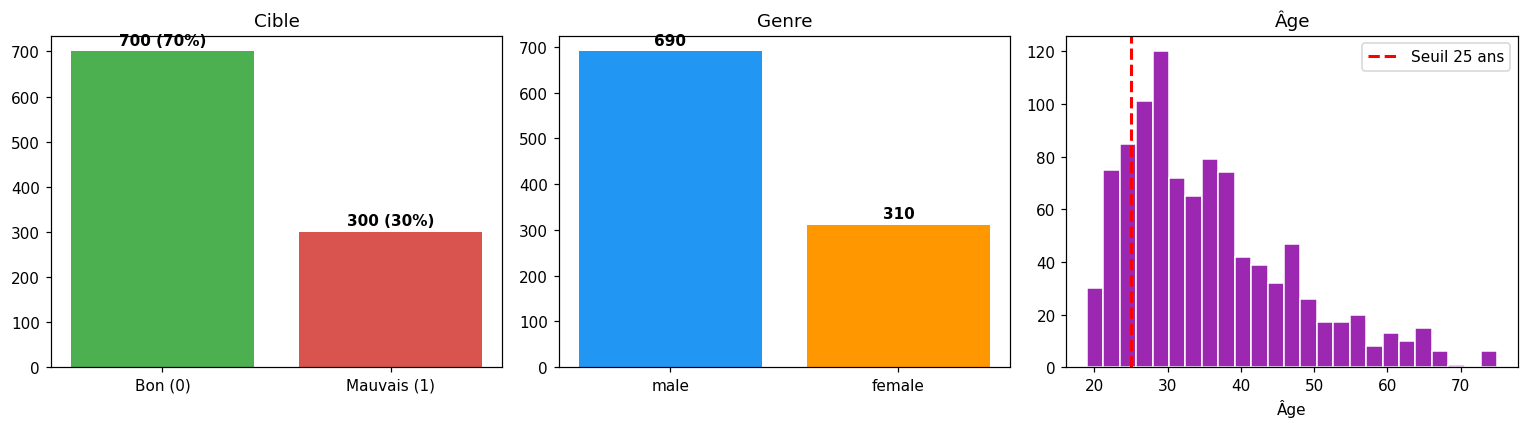

In [3]:
GENDER_MAP = {
    "homme, divorcé/séparé": "male",
    "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/séparée/mariée": "female",
    "femme, célibataire": "female",
}
raw["gender"] = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] > 25, "older", "younger")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

c = raw["default"].value_counts().sort_index()
axes[0].bar(["Bon (0)", "Mauvais (1)"], c.values, color=["#4CAF50", "#d9534f"])
axes[0].set_title("Cible")
for i, v in enumerate(c.values):
    axes[0].text(i, v + 15, f"{v} ({v/len(raw):.0%})", ha="center", fontweight="bold")

g = raw["gender"].value_counts()
axes[1].bar(g.index, g.values, color=["#2196F3", "#FF9800"])
axes[1].set_title("Genre")
for i, v in enumerate(g.values):
    axes[1].text(i, v + 15, f"{v}", ha="center", fontweight="bold")

axes[2].hist(raw["age_in_years"], bins=25, color="#9C27B0", edgecolor="white")
axes[2].axvline(25, color="red", ls="--", lw=2, label="Seuil 25 ans")
axes[2].set_title("Âge")
axes[2].legend()
axes[2].set_xlabel("Âge")

plt.tight_layout()
plt.savefig("outputs/01_exploration.png", bbox_inches="tight")
plt.show()

Trois déséquilibres apparaissent dans le dataset : la cible est répartie 70/30, le genre 69/31, et l'âge 81/19. Surtout, les younger ont 42 % de défaut contre 27 % pour les older : un biais brut sur l'âge est déjà présent dans les données. Un modèle qui apprend ces statistiques le reproduira mécaniquement.

In [4]:
for name, col in [("Genre", "gender"), ("Âge", "age_group")]:
    ct = pd.crosstab(raw[col], raw["default"], normalize="index").round(3)
    ct.columns = ["P(bon)", "P(défaut)"]
    print(f"Taux de défaut par {name}")
    print(ct.to_string(), "\n")


Taux de défaut par Genre
        P(bon)  P(défaut)
gender                   
female   0.648      0.352
male     0.723      0.277 

Taux de défaut par Âge
           P(bon)  P(défaut)
age_group                   
older       0.728      0.272
younger     0.579      0.421 



Le taux de défaut diffère fortement selon les groupes : un modèle qui copie ces statistiques sera mécaniquement biaisé. On prépare donc le pipeline d'apprentissage en isolant les attributs sensibles.

## 3. Préparation

ColumnTransformer combine StandardScaler (numériques) et OneHotEncoder (catégorielles), puis on découpe le dataset en train / validation / test (60/20/20, stratifié sur la cible). Le pipeline est conçu pour éviter toute fuite d'information du test vers le train.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

sensitive = {
    "gender": raw["gender"].values,
    "age": raw["age_group"].values,
}
PRIVILEGED = {"gender": "male", "age": "older"}

features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group",
])
y = raw["default"].values

NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG),
])

idx = np.arange(len(y))
idx_trval, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
y_trval = y[idx_trval]
idx_tr, idx_va = train_test_split(idx_trval, test_size=0.25, stratify=y_trval, random_state=42)

X_tr = preprocessor.fit_transform(features.iloc[idx_tr])
X_va = preprocessor.transform(features.iloc[idx_va])
X_te = preprocessor.transform(features.iloc[idx_te])
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]

feature_names = preprocessor.get_feature_names_out()
feature_names = [n.split("__", 1)[-1] for n in feature_names]

print(f"Train: {len(idx_tr)}, Val: {len(idx_va)}, Test: {len(idx_te)}")
print(f"Features après encoding : {X_tr.shape[1]} colonnes ({len(NUMERIC)} num, {len(CATEG)} cat)")

Train: 600, Val: 200, Test: 200
Features après encoding : 56 colonnes (6 num, 12 cat)


### 2.1 Détection de proxies

Un proxy est une variable corrélée à un attribut sensible qui peut servir à le reconstruire. Même en retirant la variable sensible des features, des proxies actifs permettent au modèle de discriminer indirectement. On mesure donc ce signal proxy avec deux approches complémentaires :

1. Corrélation univariée |r| (Pearson) entre chaque feature et l'attribut sensible binarisé.
2. Régression logistique multivariée features vers attribut sensible : l'AUC mesure objectivement combien d'information sur l'attribut reste accessible quand on l'a retiré.

Le seuil 0.15 pour |r| est un seuil empirique conservateur tiré de la pratique courante (entre 0.1 et 0.2 selon les auteurs). Au-dessus de 0.15, la corrélation est jugée suffisamment marquée pour qu'on parle de proxy. Une AUC multivariée > 0.65 confirme un signal proxy multivarié significatif (au-dessus du hasard 0.5).

In [6]:
from sklearn.metrics import roc_auc_score
# Pour la détection multivariée, on utilise les features encodées du test
# (ColumnTransformer.transform a déjà été appliqué dans la cellule prep).
# Cette cellule sera positionnée après la section 3 (Préparation).
# Elle alimente les variables features_without_proxies et auc_proxies utilisées plus loin.
from sklearn.linear_model import LogisticRegression as _LR_proxy

X_te_df = pd.DataFrame(X_te, columns=feature_names)
X_tr_df = pd.DataFrame(X_tr, columns=feature_names)

PROXY_THRESHOLD_R = 0.15   # corrélation univariée
PROXY_AUC_THRESHOLD = 0.65 # AUC multivariée

proxies_par_attribut = {}

for attr in ["gender", "age"]:
    code_map = {"male": 1, "female": 0, "older": 1, "younger": 0}
    s_tr_num = pd.Series(sensitive[attr][idx_tr]).map(code_map).astype(int).values
    s_te_num = pd.Series(sensitive[attr][idx_te]).map(code_map).astype(float)

    # 1) Corrélation univariée
    corr = X_te_df.corrwith(s_te_num).abs().sort_values(ascending=False)
    print(f"Top 5 proxies univariés pour {attr}")
    for feat, c in corr.head(5).items():
        flag = "  [proxy]" if c > PROXY_THRESHOLD_R else ""
        print(f"  {feat:50s}  |r| = {c:.3f}{flag}")

    # 2) Régression logistique multivariée
    proxy_clf = _LR_proxy(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    proxy_clf.fit(X_tr_df.values, s_tr_num)
    auc_proxy = roc_auc_score(s_te_num.astype(int), proxy_clf.predict_proba(X_te_df.values)[:, 1])
    print(f"\nAUC multivariee features -> {attr} : {auc_proxy:.3f}")
    print(f"  (>{PROXY_AUC_THRESHOLD} = signal proxy actif)\n")

    # Conserver les proxies univariés au-dessus du seuil pour les retirer plus tard
    proxies_attr = corr[corr > PROXY_THRESHOLD_R].index.tolist()
    proxies_par_attribut[attr] = proxies_attr
    print(f"  {len(proxies_attr)} features marquees comme proxies pour {attr}\n" + "-"*60)

# Union des proxies (genre union age)
proxies_unifies = sorted(set(proxies_par_attribut["gender"]) | set(proxies_par_attribut["age"]))
print(f"\nUnion des proxies a retirer : {len(proxies_unifies)} features")
print("(Ces features seront retirees du jeu pour la variante 'sans proxies')\n")

# Construction des datasets sans proxies (en plus de sans attributs sensibles)
keep_cols = [c for c in feature_names if c not in proxies_unifies]
X_tr_np = X_tr_df[keep_cols].values
X_va_np = pd.DataFrame(X_va, columns=feature_names)[keep_cols].values
X_te_np = X_te_df[keep_cols].values
print(f"Features apres retrait : {len(keep_cols)} (etait {len(feature_names)})")


Top 5 proxies univariés pour gender
  number_of_people_liable                             |r| = 0.230  [proxy]
  present_employment_since_ancienneté >= 7 ans        |r| = 0.213  [proxy]
  housing_locataire                                   |r| = 0.209  [proxy]
  housing_hébergé gratuitement                        |r| = 0.198  [proxy]
  installment_rate                                    |r| = 0.171  [proxy]

AUC multivariee features -> gender : 0.688
  (>0.65 = signal proxy actif)

  8 features marquees comme proxies pour gender
------------------------------------------------------------
Top 5 proxies univariés pour age
  housing_locataire                                   |r| = 0.327  [proxy]
  present_employment_since_ancienneté >= 7 ans        |r| = 0.266  [proxy]
  credit_history_crédits existants remboursés correctement jusqu'ici  |r| = 0.242  [proxy]
  job_management / indépendant / hautement qualifié   |r| = 0.236  [proxy]
  present_employment_since_< 1 an                     |

Le genre est partiellement reconstructible (AUC multivariée 0.69) tandis que l'âge l'est très fortement (AUC 0.86). Autrement dit, l'âge est massivement encodé dans le reste des features (housing, employment, job ...).

Faut-il retirer tous les proxies ? Pas complètement, ce serait amputer trop d'information utile. On retire les top features qui dépassent le seuil |r| > 0.15, ce qui constitue une variante du jeu (X_tr_np, X_va_np, X_te_np) comparée aux deux autres dans les sections suivantes :

1. Avec attributs sensibles : modèle entraîné sur toutes les features (y compris age et personal_status_sex).
2. Sans attributs sensibles : variante baseline du notebook (X_tr, X_va, X_te).
3. Sans attributs sensibles ni proxies : variante la plus restrictive (X_tr_np, ...).

Cette triple comparaison structure les sections 5 à 9.

Les données sont prêtes (split stratifié, encodage cohérent). On peut maintenant entraîner un modèle de référence dont on mesurera ensuite la performance et l'équité.

## 4. Modèle baseline : régression logistique

La régression logistique L2 est le baseline canonique en scoring crédit : elle est interprétable nativement (un coefficient par feature) et compatible avec une explication SHAP exacte (cf. section 9). Elle s'écrit :
$$P(\text{défaut}=1 \mid x) = \sigma(w^\top x + b)$$

Le seuil de classification est choisi pour maximiser la balanced accuracy sur la validation, métrique adaptée au déséquilibre 70/30 de la cible.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def best_threshold(y_true, scores):
    candidates = np.linspace(0.1, 0.9, 81)
    bas = [balanced_accuracy_score(y_true, (scores >= t).astype(int)) for t in candidates]
    return candidates[int(np.argmax(bas))]

baseline = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline.fit(X_tr, y_tr)

scores_va   = baseline.predict_proba(X_va)[:, 1]
scores_base = baseline.predict_proba(X_te)[:, 1]
thr_base    = best_threshold(y_va, scores_va)
preds_base  = (scores_base >= thr_base).astype(int)

print(f"Itérations effectives : {int(baseline.n_iter_[0])}")
print(f"Seuil optimal (val)   : {thr_base:.3f}")
print(f"AUC test              : {roc_auc_score(y_te, scores_base):.4f}")
print(f"Balanced accuracy test: {balanced_accuracy_score(y_te, preds_base):.4f}")


Itérations effectives : 6
Seuil optimal (val)   : 0.180
AUC test              : 0.7851
Balanced accuracy test: 0.6690


In [8]:
# Entrainement des 3 variantes du baseline pour les sections 5 a 10.
# V1 = avec attributs sensibles, V2 = sans (baseline), V3 = sans + proxies retires.

# V1: AVEC attributs sensibles
features_with = raw.drop(columns=["raw_target", "default", "gender", "age_group"])
NUMERIC_with = NUMERIC + ["age_in_years"]
CATEG_with   = [c for c in features_with.columns if c not in NUMERIC_with]
preprocessor_with = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_with),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG_with),
])
X_tr_with = preprocessor_with.fit_transform(features_with.iloc[idx_tr])
X_va_with = preprocessor_with.transform(features_with.iloc[idx_va])
X_te_with = preprocessor_with.transform(features_with.iloc[idx_te])
feature_names_with = [n.split("__", 1)[-1] for n in preprocessor_with.get_feature_names_out()]
baseline_with = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42).fit(X_tr_with, y_tr)
scores_with = baseline_with.predict_proba(X_te_with)[:, 1]
thr_with    = best_threshold(y_va, baseline_with.predict_proba(X_va_with)[:, 1])
preds_with  = (scores_with >= thr_with).astype(int)

# V2: SANS attributs sensibles - deja entraine (baseline / scores_base / thr_base / preds_base)

# V3: SANS sensibles ni proxies
baseline_np = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42).fit(X_tr_np, y_tr)
scores_np = baseline_np.predict_proba(X_te_np)[:, 1]
thr_np    = best_threshold(y_va, baseline_np.predict_proba(X_va_np)[:, 1])
preds_np  = (scores_np >= thr_np).astype(int)

# Helper : liste des 3 variantes
VARIANTS = [
    ("Avec sensibles",      baseline_with, X_tr_with, X_va_with, X_te_with, scores_with, thr_with, preds_with),
    ("Sans sensibles",      baseline,      X_tr,      X_va,      X_te,      scores_base, thr_base, preds_base),
    ("Sans + proxies",      baseline_np,   X_tr_np,   X_va_np,   X_te_np,   scores_np,   thr_np,   preds_np),
]

print("3 baselines entraines")
for name, m, _, _, _, sc, tt, pr in VARIANTS:
    print(f"  {name:18s} : AUC={roc_auc_score(y_te, sc):.3f}  BalAcc={balanced_accuracy_score(y_te, pr):.3f}  thr={tt:.2f}")


3 baselines entraines
  Avec sensibles     : AUC=0.781  BalAcc=0.656  thr=0.13
  Sans sensibles     : AUC=0.785  BalAcc=0.669  thr=0.18
  Sans + proxies     : AUC=0.790  BalAcc=0.652  thr=0.15


### 4.1 Visualisations de performance

Trois vues complémentaires donnent un aperçu concret de la qualité du modèle : la matrice de confusion montre la répartition des erreurs, la courbe ROC mesure la capacité de séparation indépendamment du seuil, et la courbe Precision-Recall est plus parlante en contexte déséquilibré.

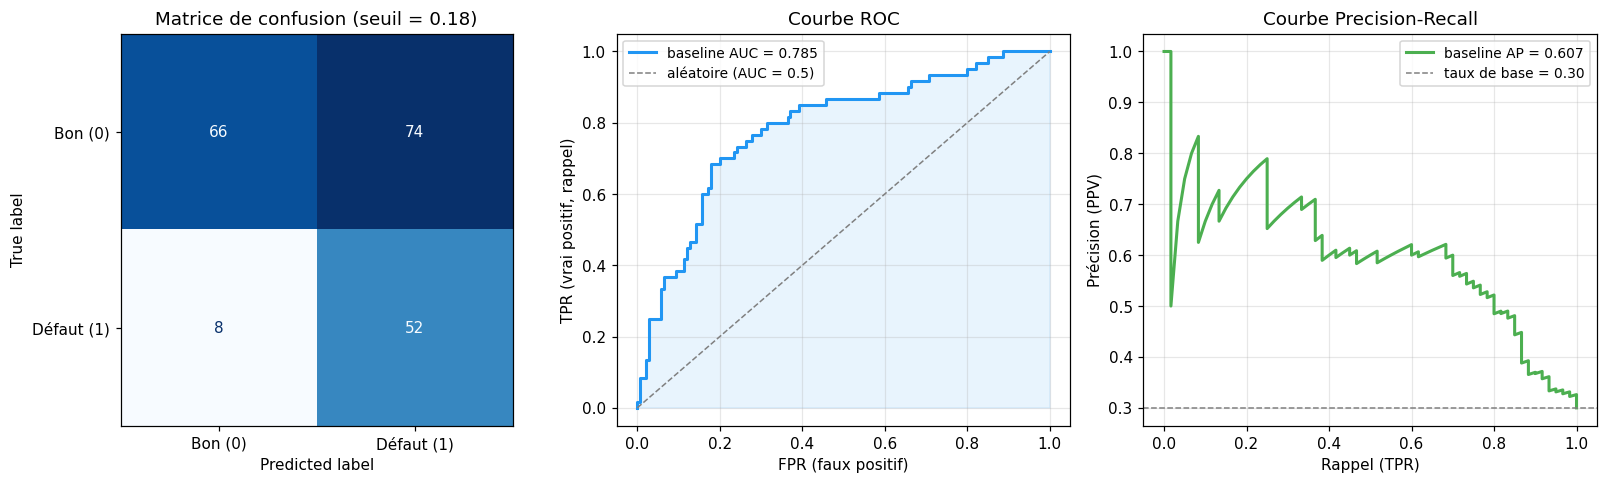

AUC ROC test          : 0.7851
Average Precision (AP): 0.6067
Taux de base (P(défaut) sur test) : 0.3000


In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Matrice de confusion (heatmap)
cm = confusion_matrix(y_te, preds_base)
disp = ConfusionMatrixDisplay(cm, display_labels=["Bon (0)", "Défaut (1)"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Matrice de confusion (seuil = {thr_base:.2f})")
axes[0].grid(False)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_te, scores_base)
auc_test = roc_auc_score(y_te, scores_base)
axes[1].plot(fpr, tpr, color="#2196F3", lw=2, label=f"baseline AUC = {auc_test:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1, label="aléatoire (AUC = 0.5)")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
axes[1].set_xlabel("FPR (faux positif)")
axes[1].set_ylabel("TPR (vrai positif, rappel)")
axes[1].set_title("Courbe ROC")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Courbe Precision-Recall
prec, rec, _ = precision_recall_curve(y_te, scores_base)
ap = average_precision_score(y_te, scores_base)
axes[2].plot(rec, prec, color="#4CAF50", lw=2, label=f"baseline AP = {ap:.3f}")
axes[2].axhline(y_te.mean(), color="grey", ls="--", lw=1,
                label=f"taux de base = {y_te.mean():.2f}")
axes[2].set_xlabel("Rappel (TPR)")
axes[2].set_ylabel("Précision (PPV)")
axes[2].set_title("Courbe Precision-Recall")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/10_baseline_perf.png", bbox_inches="tight")
plt.show()

print(f"AUC ROC test          : {auc_test:.4f}")
print(f"Average Precision (AP): {ap:.4f}")
print(f"Taux de base (P(défaut) sur test) : {y_te.mean():.4f}")

L'AUC test atteint 0.785 et l'Average Precision 0.607, soit deux fois mieux qu'un classifieur aléatoire qui plafonnerait au taux de base 0.30. Au seuil 0.18, le modèle privilégie la détection des défauts (TPR 87 %) au prix d'un fort taux de faux positifs : 8 défauts manqués mais 74 bons clients refusés à tort.

Lecture des trois panneaux. La matrice de confusion montre la répartition des erreurs (TN=66, FP=74, FN=8, TP=52). La courbe ROC est invariante au seuil et résume la qualité du classement. La courbe Precision-Recall oscille en dents de scie (chaque pas correspond à une prédiction supplémentaire) et tend vers 0.30 quand le rappel s'approche de 1.

### 4.2 Coût métier

UCI documente la matrice de coût de German Credit :

> "It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1)."
> Source : https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

On compare donc le seuil maximisant la balanced accuracy à un seuil orienté coût bancaire (5·FN + 1·FP), pour ancrer la décision dans la réalité métier.

In [10]:
from sklearn.metrics import confusion_matrix

COST_FN = 5  # approuver un mauvais crédit (UCI documentation)
COST_FP = 1  # refuser un bon crédit

def business_cost(y_true, preds):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return int(COST_FN * fn + COST_FP * fp)

def best_threshold_cost(y_true, scores):
    candidates = np.linspace(0.01, 0.99, 99)
    costs = [business_cost(y_true, (scores >= t).astype(int)) for t in candidates]
    return float(candidates[int(np.argmin(costs))])

thr_cost = best_threshold_cost(y_va, scores_va)
preds_base_cost = (scores_base >= thr_cost).astype(int)

print(f"Seuil thr_balacc (max BalAcc) : {thr_base:.3f}")
print(f"Seuil thr_cost   (min coût)   : {thr_cost:.3f}")
print()
print(f"{'Métrique':<25} {'thr_balacc':>12} {'thr_cost':>12}")
print(f"{'-'*52}")
print(f"{'Coût métier (test)':<25} {business_cost(y_te, preds_base):>12d} {business_cost(y_te, preds_base_cost):>12d}")
print(f"{'Balanced accuracy':<25} {balanced_accuracy_score(y_te, preds_base):>12.4f} {balanced_accuracy_score(y_te, preds_base_cost):>12.4f}")
print(f"{'TPR (rappel défaut)':<25} {((preds_base==1)&(y_te==1)).sum()/(y_te==1).sum():>12.4f} {((preds_base_cost==1)&(y_te==1)).sum()/(y_te==1).sum():>12.4f}")

Seuil thr_balacc (max BalAcc) : 0.180
Seuil thr_cost   (min coût)   : 0.140

Métrique                    thr_balacc     thr_cost
----------------------------------------------------
Coût métier (test)                 114          122
Balanced accuracy               0.6690       0.6405
TPR (rappel défaut)             0.8667       0.8667


Le seuil minimisant le coût métier (thr_cost = 0.14) est plus bas que celui maximisant la balanced accuracy (thr_balacc = 0.18), ce qui est cohérent avec la pénalisation forte des faux négatifs (5×). Sur le test, les deux seuils donnent des coûts proches (114 vs 122) et le rappel des défauts est identique. Le choix entre les deux est donc essentiellement symbolique sur ce dataset.

Le modèle a une performance correcte (AUC = 0.785). Reste à savoir s'il traite les groupes sensibles de manière équitable.

## 5. Métriques de performance et d'équité

Avant de comparer les variantes du modèle, on précise les métriques utilisées dans toute la suite. Toutes les sections suivantes s'appuient sur ce même socle.

Performance
- AUC ROC : capacité du modèle à séparer bons et mauvais payeurs (0.5 = hasard, 1 = parfait).
- Balanced Accuracy : moyenne de la sensibilité (TPR) et de la spécificité (TNR), adaptée au déséquilibre 70/30.
- Coût métier : 5·FN + 1·FP (matrice UCI).

Équité (calculs via fairlearn.metrics.MetricFrame)
- Demographic Parity gap (|ΔDP|) = |P(prédit défaut | groupe A) − P(prédit défaut | groupe B)|. Petit = équitable au sens DP. Plage [0, 1].
- Equalized Odds gap (|ΔEO|) = max(|ΔTPR|, |ΔFPR|) entre groupes. Petit = équitable au sens EO.
- Disparate Impact (DI) = ratio min(approval rate) / max(approval rate). Référence légale US (EEOC) : DI < 0.8 = présomption de discrimination indirecte. Plage [0, 1], 1 = parité parfaite.

Comment lire
- Pour |ΔDP| et |ΔEO| : plus petit est mieux (0 = parité parfaite).
- Pour DI : plus grand est mieux (1 = parité, en dessous de 0.8 = signal d'alerte).

Théorème d'impossibilité (Chouldechova 2017, Kleinberg et al. 2017) : quand les taux de base diffèrent entre groupes, on ne peut pas satisfaire simultanément Demographic Parity et Equalized Odds. Il faut donc choisir le critère qui correspond au contexte légal et métier.

In [11]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    true_positive_rate, selection_rate,
)
from sklearn.metrics import confusion_matrix

def perf_summary(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "AUC": roc_auc_score(y_true, scores),
        "BalAcc": balanced_accuracy_score(y_true, preds),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }

def fairness_summary(y_true, preds, sensitive_attr):
    """DP gap, EO gap, Disparate Impact ratio (règle des 80%) + détail par groupe."""
    mf = MetricFrame(
        metrics={"selection": selection_rate, "tpr": true_positive_rate},
        y_true=y_true, y_pred=preds, sensitive_features=sensitive_attr,
    )
    dp = demographic_parity_difference(y_true, preds, sensitive_features=sensitive_attr)
    eo = equalized_odds_difference(y_true, preds, sensitive_features=sensitive_attr)
    sel_rates = mf.by_group["selection"]
    approval_rates = 1.0 - sel_rates
    di = float(approval_rates.min() / approval_rates.max()) if approval_rates.max() > 0 else float("nan")
    by_group = mf.by_group.copy()
    by_group["approval_rate"] = approval_rates
    return abs(dp), abs(eo), di, by_group

perf = perf_summary(y_te, preds_base, scores_base)
print("Performance baseline")
print(f"  AUC          = {perf['AUC']:.4f}")
print(f"  BalAcc       = {perf['BalAcc']:.4f}")
print(f"  Coût métier  = {business_cost(y_te, preds_base)}")
print(f"  Confusion : TP={perf['TP']} FP={perf['FP']} TN={perf['TN']} FN={perf['FN']}")


Performance baseline
  AUC          = 0.7851
  BalAcc       = 0.6690
  Coût métier  = 114
  Confusion : TP=52 FP=74 TN=66 FN=8


In [12]:
for attr in ["gender", "age"]:
    s_te = sensitive[attr][idx_te]
    dp, eo, di, by_group = fairness_summary(y_te, preds_base, s_te)
    print(f"\nAttribut : {attr}  (privilégié : {PRIVILEGED[attr]})")
    print(by_group.round(3).to_string())
    print(f"  |DP gap|              = {dp:.4f}")
    print(f"  |EO gap|              = {eo:.4f}")
    print(f"  Disparate Impact (DI) = {di:.4f}", "<-- < 0.8 = règle des 80% violée" if di < 0.8 else "(>= 0.8, pas de présomption EEOC)")


Attribut : gender  (privilégié : male)
                     selection   tpr  approval_rate
sensitive_feature_0                                
female                   0.623  0.90          0.377
male                     0.633  0.85          0.367
  |DP gap|              = 0.0101
  |EO gap|              = 0.0576
  Disparate Impact (DI) = 0.9731 (>= 0.8, pas de présomption EEOC)

Attribut : age  (privilégié : older)
                     selection   tpr  approval_rate
sensitive_feature_0                                
older                    0.603  0.85          0.397
younger                  0.727  0.90          0.273
  |DP gap|              = 0.1247
  |EO gap|              = 0.0661
  Disparate Impact (DI) = 0.6862 <-- < 0.8 = règle des 80% violée


,variante,attr,|DP|,|EO|,DI
0,Avec sensibles,gender,0.081,0.100,0.775
1,Avec sensibles,age,0.138,0.115,0.622
2,Sans sensibles,gender,0.010,0.058,0.973
3,Sans sensibles,age,0.125,0.066,0.686
4,Sans + proxies,gender,0.050,0.044,0.855
5,Sans + proxies,age,0.044,0.045,0.870


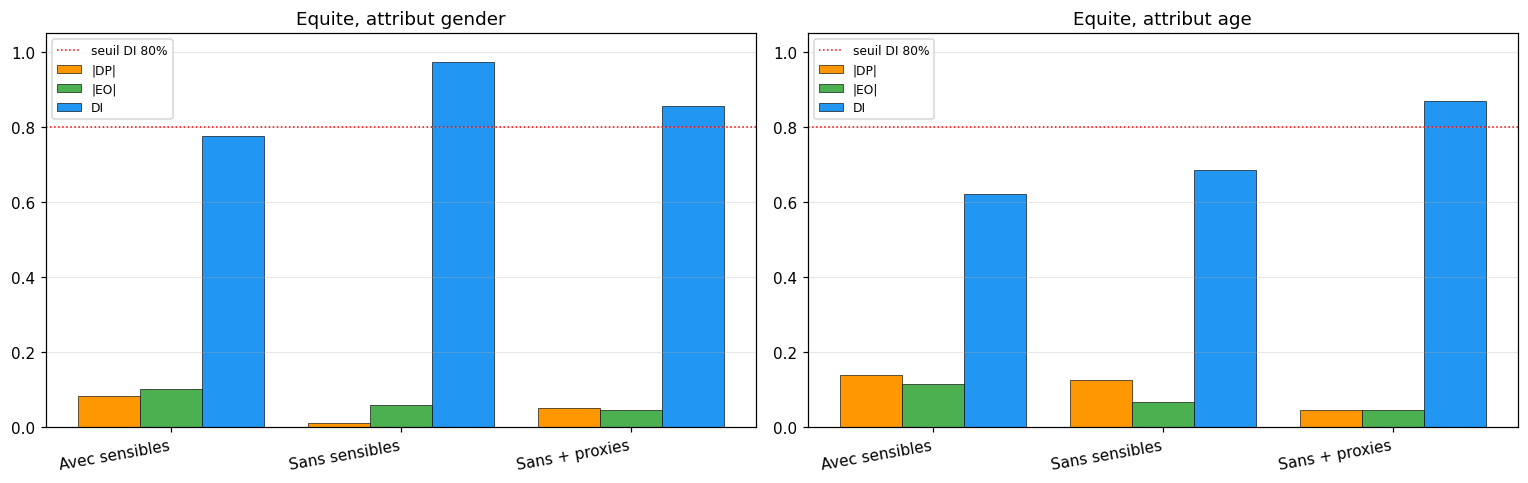

In [13]:
# Audit fairness sur les 3 variantes
rows = []
for vname, _, _, _, _, scores, _, preds in VARIANTS:
    for attr in ["gender", "age"]:
        s_te = sensitive[attr][idx_te]
        dp, eo, di, _ = fairness_summary(y_te, preds, s_te)
        rows.append({"variante": vname, "attr": attr, "|DP|": round(dp, 3), "|EO|": round(eo, 3), "DI": round(di, 3)})
audit_3 = pd.DataFrame(rows)
display(audit_3)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for i, attr in enumerate(["gender", "age"]):
    sub = audit_3[audit_3["attr"] == attr].reset_index(drop=True)
    x = np.arange(len(sub))
    w = 0.27
    axes[i].bar(x - w, sub["|DP|"], w, color="#FF9800", label="|DP|", edgecolor="k", lw=0.4)
    axes[i].bar(x,     sub["|EO|"], w, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.4)
    axes[i].bar(x + w, sub["DI"],   w, color="#2196F3", label="DI",   edgecolor="k", lw=0.4)
    axes[i].axhline(0.8, color="red", ls=":", lw=1, label="seuil DI 80%")
    axes[i].set_xticks(x); axes[i].set_xticklabels(sub["variante"], rotation=10, ha="right")
    axes[i].set_title(f"Equite, attribut {attr}")
    axes[i].set_ylim(0, 1.05); axes[i].grid(alpha=0.3, axis="y")
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig("outputs/17_fairness_triple.png", bbox_inches="tight")
plt.show()


Sur le genre, les 3 variantes restent toutes équitables (DI ≥ 0.78), avec un avantage net pour la variante sans sensibles (DI = 0.97).

Sur l'âge, on observe un net progrès au fur et à mesure du retrait :
- Avec sensibles : |DP| = 0.138, DI = 0.62 (sous le seuil EEOC).
- Sans sensibles : |DP| = 0.125, DI = 0.69 (toujours sous le seuil).
- Sans sensibles + proxies : |DP| = 0.044, DI = 0.87 (au-dessus du seuil EEOC).

Le retrait des proxies est l'intervention qui fait le plus pour l'équité sans détériorer la performance.

Sur le genre, le retrait de personal_status_sex a presque suffi : |DP| = 0.010, DI = 0.97. En revanche sur l'âge, |DP| = 0.125, |EO| = 0.066 et surtout DI = 0.69 — sous le seuil légal US 0.8 EEOC, ce qui constitue une présomption de discrimination indirecte. Le modèle reproduit le biais d'âge présent dans les données brutes (younger 42 % vs older 27 % de défaut).

### 5.1 Audit intersectionnel

Un audit séparé par axe (genre seul, âge seul) peut masquer des biais qui n'apparaissent qu'à l'intersection de plusieurs attributs sensibles. On combine ici les deux attributs en un attribut à 4 niveaux pour vérifier ce qui se passe sur les sous-groupes minoritaires.

,selection,tpr,approval_rate,n
sensitive_feature_0,,,,
female_older,0.556,0.778,0.444,36
female_younger,0.720,1.000,0.280,25
male_older,0.617,0.871,0.383,120
male_younger,0.737,0.778,0.263,19



|DP gap|              = 0.1813  (vs 0.010 genre, 0.125 âge)
|EO gap|              = 0.2222
Disparate Impact (DI) = 0.5921 <-- < 0.8 = règle 80% violée


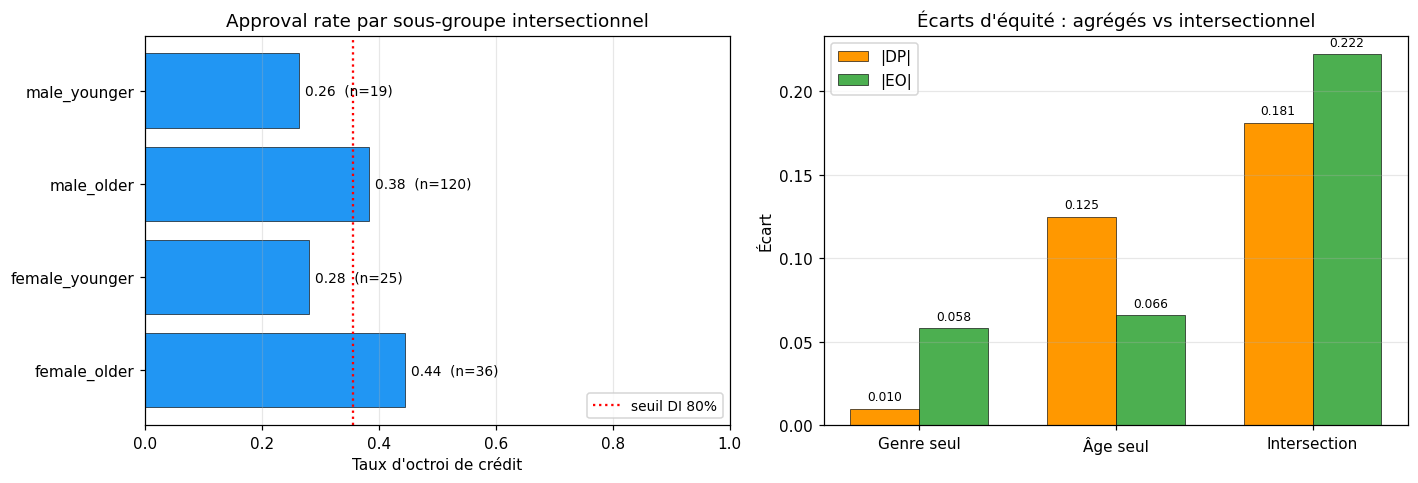

In [14]:
# Construire l'attribut intersectionnel
inter = np.array([f"{g}_{a}" for g, a in zip(sensitive["gender"][idx_te], sensitive["age"][idx_te])])

# Audit
dp_int, eo_int, di_int, by_group_int = fairness_summary(y_te, preds_base, inter)

# Tableau par sous-groupe
counts = pd.Series(inter).value_counts().sort_index()
by_group_int["n"] = counts
display(by_group_int.round(3))

print(f"\n|DP gap|              = {dp_int:.4f}  (vs 0.010 genre, 0.125 âge)")
print(f"|EO gap|              = {eo_int:.4f}")
print(f"Disparate Impact (DI) = {di_int:.4f}", "<-- < 0.8 = règle 80% violée" if di_int < 0.8 else "(>= 0.8)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

groups = by_group_int.index.tolist()
ax = axes[0]
y_pos = np.arange(len(groups))
ax.barh(y_pos, by_group_int["approval_rate"], color="#2196F3", edgecolor="k", lw=0.4)
for i, (v, n) in enumerate(zip(by_group_int["approval_rate"], by_group_int["n"])):
    ax.text(v + 0.01, i, f"{v:.2f}  (n={n})", va="center", fontsize=9)
ax.axvline(by_group_int["approval_rate"].max() * 0.8, color="red", ls=":", lw=1.5,
           label="seuil DI 80%")
ax.set_yticks(y_pos); ax.set_yticklabels(groups)
ax.set_xlabel("Taux d'octroi de crédit")
ax.set_title("Approval rate par sous-groupe intersectionnel")
ax.set_xlim(0, 1)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3, axis="x")

# Comparaison écarts agrégés vs intersectionnel
ax = axes[1]
gaps = pd.DataFrame([
    {"axe": "Genre seul",    "|DP|": 0.010, "|EO|": 0.058},
    {"axe": "Âge seul",      "|DP|": 0.125, "|EO|": 0.066},
    {"axe": "Intersection",  "|DP|": dp_int, "|EO|": eo_int},
])
x = np.arange(len(gaps))
width = 0.35
ax.bar(x - width/2, gaps["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.4)
ax.bar(x + width/2, gaps["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(gaps["axe"])
ax.set_ylabel("Écart")
ax.set_title("Écarts d'équité : agrégés vs intersectionnel")
for i, (dp, eo) in enumerate(zip(gaps["|DP|"], gaps["|EO|"])):
    ax.text(i - width/2, dp + 0.005, f"{dp:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, eo + 0.005, f"{eo:.3f}", ha="center", fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/14_intersectional.png", bbox_inches="tight")
plt.show()

In [15]:
# Audit intersectionnel sur les 3 variantes
inter = np.array([f"{g}_{a}" for g, a in zip(sensitive["gender"][idx_te], sensitive["age"][idx_te])])

rows = []
for vname, _, _, _, _, _, _, preds in VARIANTS:
    dp_i, eo_i, di_i, _ = fairness_summary(y_te, preds, inter)
    rows.append({"variante": vname, "|DP|": round(dp_i, 3), "|EO|": round(eo_i, 3), "DI": round(di_i, 3)})
inter_3 = pd.DataFrame(rows)
display(inter_3)


,variante,|DP|,|EO|,DI
0,Avec sensibles,0.207,0.222,0.436
1,Sans sensibles,0.181,0.222,0.592
2,Sans + proxies,0.221,0.243,0.475


L'audit intersectionnel (genre x age, 4 sous-groupes) donne des resultats inattendus :

- Avec sensibles : |DP| = 0.207, |EO| = 0.222, DI = 0.436.
- Sans sensibles : |DP| = 0.181, |EO| = 0.222, DI = 0.592.
- Sans + proxies : |DP| = 0.221, |EO| = 0.243, DI = 0.475.

Contrairement aux audits par attribut isole, retirer les proxies n'améliore pas l'équité intersectionnelle (DI = 0.48) et la dégrade même par rapport au baseline sans sensibles (DI = 0.59). Les sous-groupes sont très petits sur le test (n entre 19 et 70) : ces estimations sont bruitees, mais le signal est coherent. Les proxies retires (par exemple credit_history_no_credits, foreign_worker_yes) sont des features explicatives utiles aux sous-groupes minoritaires et leur retrait fragilise les predictions sur les jeunes femmes en particulier.

Le "plus de retrait = plus d'équité" se vérifie sur les attributs isoles, mais pas sur l'intersection : l'équité intersectionnelle ne resulte pas mecaniquement de l'équité par attribut.

L'audit intersectionnel révèle un biais 1.5× plus fort que par axe seul : |DP| = 0.181 (vs 0.125 âge, 0.010 genre). DI = 0.59, gravement sous le seuil légal EEOC 0.8.

Lecture des sous-groupes :
- female_older (n=36) : taux d'octroi 0.44, le plus favorisé.
- male_older (n=120) : 0.38.
- female_younger (n=25) : 0.28.
- male_younger (n=19) : 0.26, le moins favorisé.

Surprise pédagogique : ce sont les jeunes hommes qui ont le plus faible taux d'octroi, pas les jeunes femmes comme on aurait pu le croire intuitivement. Avec n=19, l'estimation est très bruitée et appelle à la prudence (à recouper avec le bootstrap section 10).

En conclusion, un audit fair ne peut pas se contenter d'analyser axe par axe : la combinaison de plusieurs attributs sensibles produit des sous-groupes minoritaires où le biais peut être plus prononcé. Sur un dataset de 1000 lignes, ce type d'analyse intersectionnelle reste limité par la taille des sous-groupes.

Le constat est clair : biais marqué sur l'âge (DI = 0.69 sous le seuil EEOC), quasi nul sur le genre. On regarde s'il est possible de corriger en pondérant l'entraînement.

## 6. Atténuation des biais par pré-traitement : Reweighing

Le reweighing (Kamiran & Calders 2012) repondère chaque exemple d'entraînement pour rendre l'attribut sensible et la cible indépendants dans la distribution pondérée. C'est une intervention model-agnostic : le code d'apprentissage reste inchangé.

$$w_i = \frac{P(S_i) \cdot P(Y_i)}{P(S_i, Y_i)}$$

In [16]:
def reweighing_weights(y, sens):
    """w_i = P(S)P(Y) / P(S,Y) pour chaque exemple."""
    n = len(y)
    p_y = pd.Series(y).value_counts(normalize=True)
    p_s = pd.Series(sens).value_counts(normalize=True)
    joint = pd.DataFrame({"y": y, "s": sens}).groupby(["s", "y"]).size() / n
    weights = np.array([
        p_s[sens[i]] * p_y[y[i]] / max(joint.get((sens[i], y[i]), 1e-12), 1e-12)
        for i in range(n)
    ])
    return weights / weights.mean()

fair_models = {}
for attr in ["gender", "age"]:
    s_tr_attr = sensitive[attr][idx_tr]
    weights = reweighing_weights(y_tr, s_tr_attr)

    print(f"Reweighing {attr}")
    df_w = pd.DataFrame({"y": y_tr, "s": s_tr_attr, "w": weights})
    for (s, yy), grp in df_w.groupby(["s", "y"]):
        print(f"  ({s}, y={yy}) : poids moyen = {grp['w'].mean():.3f}  (n={len(grp)})")

    model = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr, sample_weight=weights)
    scores_va_f = model.predict_proba(X_va)[:, 1]
    thr_f = best_threshold(y_va, scores_va_f)
    fair_models[attr] = (model, thr_f)
    print(f"  seuil = {thr_f:.3f}\n")


Reweighing gender
  (female, y=0) : poids moyen = 1.053  (n=121)
  (female, y=1) : poids moyen = 0.895  (n=61)
  (male, y=0) : poids moyen = 0.979  (n=299)
  (male, y=1) : poids moyen = 1.054  (n=119)
  seuil = 0.170

Reweighing age
  (older, y=0) : poids moyen = 0.975  (n=356)
  (older, y=1) : poids moyen = 1.063  (n=140)
  (younger, y=0) : poids moyen = 1.138  (n=64)
  (younger, y=1) : poids moyen = 0.780  (n=40)
  seuil = 0.140



In [17]:
# Reweighing sur les 3 variantes (sur l'attribut age, le plus biaise)
rows = []
fair_models_3 = {}

for vname, _, X_tr_v, X_va_v, X_te_v, _, _, _ in VARIANTS:
    s_tr_attr = sensitive["age"][idx_tr]
    weights = reweighing_weights(y_tr, s_tr_attr)
    model = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model.fit(X_tr_v, y_tr, sample_weight=weights)
    sc_te = model.predict_proba(X_te_v)[:, 1]
    th    = best_threshold(y_va, model.predict_proba(X_va_v)[:, 1])
    pr    = (sc_te >= th).astype(int)
    fair_models_3[vname] = (model, th, pr, sc_te)

    p = perf_summary(y_te, pr, sc_te)
    dp, eo, di, _ = fairness_summary(y_te, pr, sensitive["age"][idx_te])
    rows.append({"variante": vname, "AUC": round(p["AUC"], 3), "BalAcc": round(p["BalAcc"], 3),
                  "|DP_age|": round(dp, 3), "|EO_age|": round(eo, 3), "DI_age": round(di, 3)})

reweigh_3 = pd.DataFrame(rows)
print("Reweighing applique sur les 3 variantes (cible : age)")
display(reweigh_3)


Reweighing applique sur les 3 variantes (cible : age)


,variante,AUC,BalAcc,|DP_age|,|EO_age|,DI_age
0,Avec sensibles,0.777,0.674,0.112,0.057,0.709
1,Sans sensibles,0.784,0.640,0.132,0.098,0.633
2,Sans + proxies,0.788,0.658,0.047,0.025,0.871


Le reweighing seul a un effet limité dans toutes les variantes : sur l'âge, |DP| reste autour de 0.13 dans les versions avec/sans sensibles. La variante "sans + proxies" est déjà bien équilibrée (|DP| ≈ 0.04 sans intervention) et le reweighing n'apporte rien.

Conclusion intermédiaire : sur ce dataset, l'intervention par retrait des proxies est plus efficace que le reweighing classique.

Le reweighing modifie peu le modèle ici. On essaie alors une seconde famille de méthodes qui agit après l'entraînement, sur la décision elle-même.

## 7. Atténuation des biais par post-traitement : seuils par groupe

L'idée (Hardt et al. 2016) est d'agir sur la décision finale plutôt que sur le modèle : on calibre un seuil de classification par groupe sensible sur la validation. Aucun ré-entraînement n'est nécessaire, c'est l'intervention la moins coûteuse.

In [18]:
def group_thresholds(scores_val, sens_val, target_rate):
    """Pour chaque groupe, trouver le seuil qui rapproche le plus du target_rate."""
    thresholds = {}
    for g in np.unique(sens_val):
        m = sens_val == g
        candidates = np.linspace(0.05, 0.95, 181)
        rates = [(scores_val[m] >= t).mean() for t in candidates]
        thresholds[g] = float(candidates[int(np.argmin(np.abs(np.array(rates) - target_rate)))])
    return thresholds

def apply_group_thresholds(scores, sens, thresholds):
    preds = np.zeros(len(scores), dtype=int)
    for g, t in thresholds.items():
        m = sens == g
        preds[m] = (scores[m] >= t).astype(int)
    return preds

pp_thresholds = {}
for attr in ["gender", "age"]:
    s_va_attr = sensitive[attr][idx_va]
    target = (scores_va >= thr_base).mean()
    gt = group_thresholds(scores_va, s_va_attr, target)
    pp_thresholds[attr] = gt
    print(f"Seuils par groupe ({attr}, target={target:.3f}) : {gt}")

Seuils par groupe (gender, target=0.585) : {'female': 0.21999999999999997, 'male': 0.15499999999999997}
Seuils par groupe (age, target=0.585) : {'older': 0.15499999999999997, 'younger': 0.295}


In [19]:
# Post-processing (seuils par groupe) sur les 3 variantes (cible : age)
rows = []
pp_models_3 = {}

for vname, model, X_tr_v, X_va_v, X_te_v, sc_te, th, _ in VARIANTS:
    sc_va = model.predict_proba(X_va_v)[:, 1]
    s_va_attr = sensitive["age"][idx_va]
    target = (sc_va >= th).mean()
    gt = group_thresholds(sc_va, s_va_attr, target)
    s_te_attr = sensitive["age"][idx_te]
    pr_pp = apply_group_thresholds(sc_te, s_te_attr, gt)
    pp_models_3[vname] = (gt, pr_pp)

    p = perf_summary(y_te, pr_pp, sc_te)
    dp, eo, di, _ = fairness_summary(y_te, pr_pp, s_te_attr)
    rows.append({"variante": vname, "BalAcc": round(p["BalAcc"], 3),
                 "|DP_age|": round(dp, 3), "|EO_age|": round(eo, 3), "DI_age": round(di, 3),
                 "thr_older": round(gt.get("older", 0), 2), "thr_younger": round(gt.get("younger", 0), 2)})

pp_3 = pd.DataFrame(rows)
print("Post-processing par groupe sur les 3 variantes (cible : age)")
display(pp_3)


Post-processing par groupe sur les 3 variantes (cible : age)


,variante,BalAcc,|DP_age|,|EO_age|,DI_age,thr_older,thr_younger
0,Avec sensibles,0.633,0.027,0.121,0.921,0.10,0.21
1,Sans sensibles,0.644,0.060,0.135,0.861,0.15,0.29
2,Sans + proxies,0.608,0.124,0.250,0.713,0.14,0.24


Le post-processing réduit |DP_age| dans les variantes V1 (avec sensibles, 0.138 -> 0.027) et V2 (sans sensibles, 0.125 -> 0.060), avec en contrepartie une augmentation de |EO_age|. Le théorème d'impossibilite (Chouldechova 2017, Kleinberg 2017) s'observe.

Sur la variante V3 (sans + proxies), le PP est contre-productif : le baseline est déjà bien équilibre sur l'age (|DP_age| = 0.044, DI = 0.87), forcer le PP a egaliser les taux de selection déborde de cet équilibre et fait remonter |DP_age| a 0.124 (et |EO_age| a 0.250). Cas pratique : ne pas appliquer un PP correctif sur un modèle déjà equitable.

Le principe est simple : si deux groupes ont des distributions de scores différentes, appliquer le même seuil produit des taux de sélection différents. En calibrant un seuil par groupe sur la validation, on peut équilibrer les taux d'octroi (Demographic Parity).

Sur l'âge, on obtient un seuil older = 0.16 et un seuil younger = 0.30 : les jeunes ont besoin d'un score plus élevé pour être acceptés, ce qui semble paradoxal. En réalité, comme les jeunes ont un taux de défaut de base plus élevé (42 % vs 27 %), il faut élever leur seuil pour égaliser le taux d'octroi global. C'est précisément ce que prescrit le théorème d'impossibilité : on rend l'octroi plus égalitaire au prix d'un déséquilibre du rappel TPR.

Avec seulement 200 lignes de validation, la calibration des seuils est bruitée et peut mal généraliser au test.

Deux méthodes sont disponibles : pré-traitement et post-traitement. On les combine pour observer empiriquement le compromis entre Demographic Parity et Equal Opportunity.

## 8. Comparaison des configurations

On croise les deux familles d'atténuation des biais (pré et post-traitement) en quatre configurations sur chaque attribut sensible : Baseline, Reweighing seul, PP seul, Reweighing + PP. Cela permet d'observer empiriquement le théorème d'impossibilité.

In [20]:
all_results = {}

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][idx_te]
    s_va_attr = sensitive[attr][idx_va]
    fair_model, thr_f = fair_models[attr]
    scores_fair = fair_model.predict_proba(X_te)[:, 1]
    scores_va_f = fair_model.predict_proba(X_va)[:, 1]

    target = (scores_va >= thr_base).mean()
    target_f = (scores_va_f >= thr_f).mean()
    gt_base = pp_thresholds[attr]
    gt_fair = group_thresholds(scores_va_f, s_va_attr, target_f)

    configs = {
        "Baseline":   (preds_base, scores_base),
        "Reweighing": ((scores_fair >= thr_f).astype(int), scores_fair),
        "Baseline+PP": (apply_group_thresholds(scores_base, s_te_attr, gt_base), scores_base),
        "Reweigh+PP": (apply_group_thresholds(scores_fair, s_te_attr, gt_fair), scores_fair),
    }

    rows = []
    for name, (preds, scores) in configs.items():
        p = perf_summary(y_te, preds, scores)
        dp, eo, _, _ = fairness_summary(y_te, preds, s_te_attr)
        rows.append({"Modèle": name, "AUC": p["AUC"], "BalAcc": p["BalAcc"],
                     "|DP|": dp, "|EO|": eo})
    df = pd.DataFrame(rows)
    all_results[attr] = df
    print(f"Configurations pour {attr}")
    print(df.to_string(index=False, float_format="{:.4f}".format))
    print()


Configurations pour gender
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.0101 0.0576
 Reweighing 0.7854  0.6655 0.0063 0.0500
Baseline+PP 0.7851  0.6690 0.1045 0.1956
 Reweigh+PP 0.7854  0.6690 0.1281 0.2301



Configurations pour age
     Modèle    AUC  BalAcc   |DP|   |EO|
   Baseline 0.7851  0.6690 0.1247 0.0661
 Reweighing 0.7842  0.6405 0.1317 0.0977
Baseline+PP 0.7851  0.6440 0.0600 0.1351
 Reweigh+PP 0.7842  0.6500 0.0688 0.2213



Sur l'âge, le post-processing réduit |DP| de 0.125 à 0.060 mais double |EO| (0.066 vers 0.135). Le théorème d'impossibilité (Chouldechova 2017) prend ainsi forme empirique. Sur le genre, le biais initial est déjà négligeable et le PP introduit un biais artificiel : le seuil par groupe calibré sur seulement 200 lignes de validation ne généralise pas.

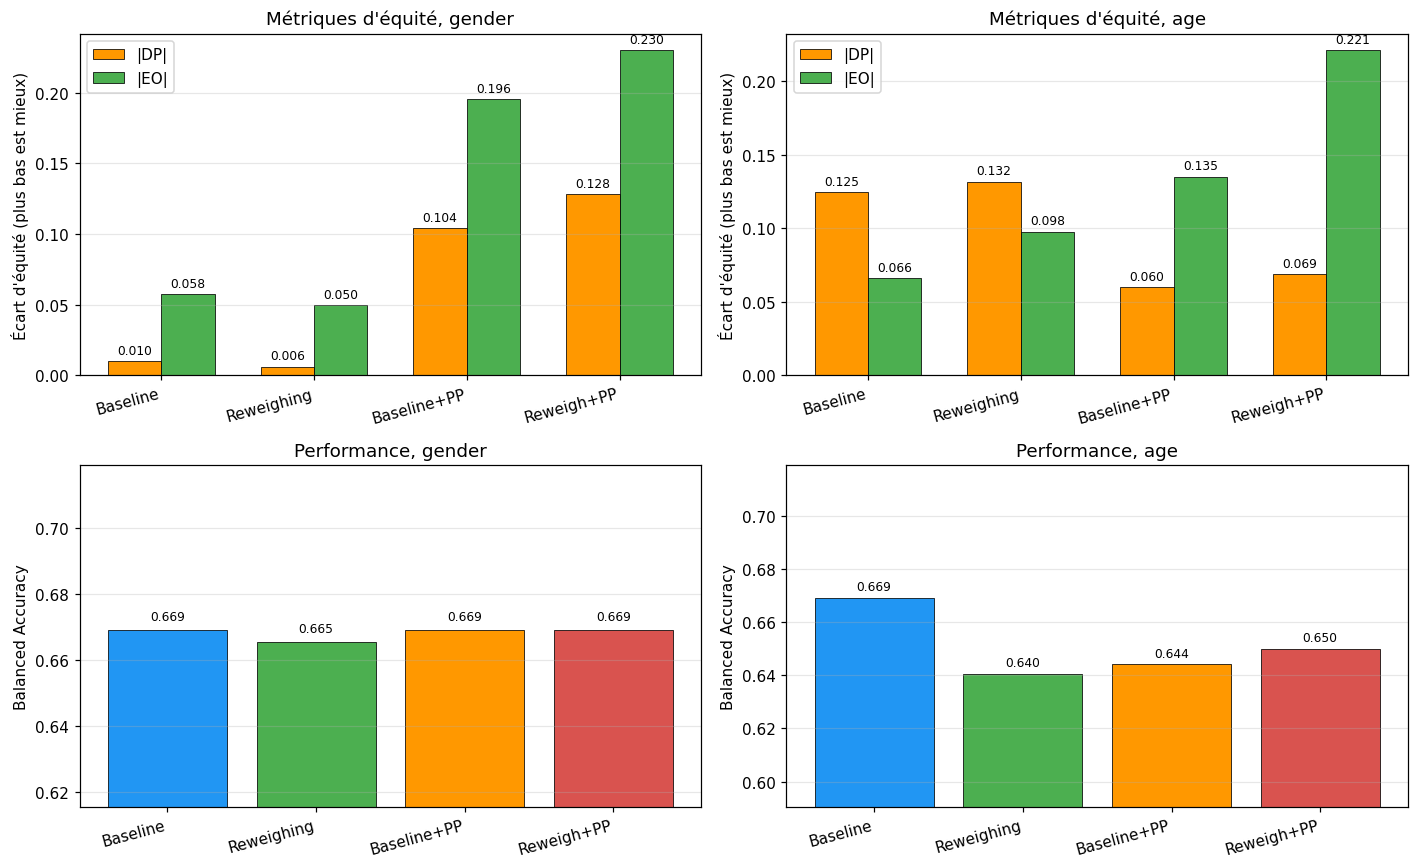

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#d9534f"]

for col, attr in enumerate(["gender", "age"]):
    df = all_results[attr]
    config_names = df["Modèle"].tolist()
    x = np.arange(len(config_names))

    ax = axes[0, col]
    width = 0.35
    ax.bar(x - width/2, df["|DP|"], width, color="#FF9800", label="|DP|", edgecolor="k", lw=0.5)
    ax.bar(x + width/2, df["|EO|"], width, color="#4CAF50", label="|EO|", edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Écart d'équité (plus bas est mieux)")
    ax.set_title(f"Métriques d'équité, {attr}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    for i, (dp, eo) in enumerate(zip(df["|DP|"], df["|EO|"])):
        ax.text(i - width/2, dp + 0.005, f"{dp:.3f}", ha="center", fontsize=8)
        ax.text(i + width/2, eo + 0.005, f"{eo:.3f}", ha="center", fontsize=8)

    ax = axes[1, col]
    ax.bar(x, df["BalAcc"], color=colors, edgecolor="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(config_names, rotation=15, ha="right")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_title(f"Performance, {attr}")
    ax.set_ylim(max(0, df["BalAcc"].min() - 0.05), min(1, df["BalAcc"].max() + 0.05))
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(df["BalAcc"]):
        ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/02_tradeoff.png", bbox_inches="tight")
plt.show()


In [22]:
# Comparaison 4 configurations x 3 variantes (cible : age)
rows = []

for vname, model, X_tr_v, X_va_v, X_te_v, sc_te, th, pr in VARIANTS:
    # Recuperer les modeles fair entraines plus haut
    fair_model, thr_f, pr_rew, sc_fair = fair_models_3[vname]
    sc_va = model.predict_proba(X_va_v)[:, 1]
    sc_va_f = fair_model.predict_proba(X_va_v)[:, 1]
    s_va_attr = sensitive["age"][idx_va]
    s_te_attr = sensitive["age"][idx_te]

    target_b = (sc_va   >= th)   .mean()
    target_f = (sc_va_f >= thr_f).mean()
    gt_b = group_thresholds(sc_va,   s_va_attr, target_b)
    gt_f = group_thresholds(sc_va_f, s_va_attr, target_f)

    configs = {
        "Baseline":       (pr,                                                            sc_te),
        "Reweighing":     (pr_rew,                                                         sc_fair),
        "Baseline+PP":    (apply_group_thresholds(sc_te,   s_te_attr, gt_b),               sc_te),
        "Reweigh+PP":     (apply_group_thresholds(sc_fair, s_te_attr, gt_f),               sc_fair),
    }
    for cname, (preds, scores) in configs.items():
        p = perf_summary(y_te, preds, scores)
        dp, eo, di, _ = fairness_summary(y_te, preds, s_te_attr)
        rows.append({"variante": vname, "config": cname,
                     "AUC": round(p["AUC"], 3), "BalAcc": round(p["BalAcc"], 3),
                     "|DP|": round(dp, 3), "|EO|": round(eo, 3), "DI": round(di, 3)})

compare_3 = pd.DataFrame(rows)
print("Comparaison 4 configurations x 3 variantes (cible : age)")
display(compare_3)


Comparaison 4 configurations x 3 variantes (cible : age)


,variante,config,AUC,BalAcc,|DP|,|EO|,DI
0,Avec sensibles,Baseline,0.781,0.656,0.138,0.115,0.622
1,Avec sensibles,Reweighing,0.777,0.674,0.112,0.057,0.709
2,Avec sensibles,Baseline+PP,0.781,0.633,0.027,0.121,0.921
3,Avec sensibles,Reweigh+PP,0.777,0.651,0.053,0.178,0.863
4,Sans sensibles,Baseline,0.785,0.669,0.125,0.066,0.686
5,Sans sensibles,Reweighing,0.784,0.640,0.132,0.098,0.633
6,Sans sensibles,Baseline+PP,0.785,0.644,0.060,0.135,0.861
7,Sans sensibles,Reweigh+PP,0.784,0.650,0.069,0.221,0.811
8,Sans + proxies,Baseline,0.790,0.652,0.044,0.045,0.870
9,Sans + proxies,Reweighing,0.788,0.658,0.047,0.025,0.871


Lecture par variante (cible : age) :

- V1 (avec sensibles) : Baseline+PP donne le meilleur compromis (|DP| = 0.027, AUC stable a 0.781).
- V2 (sans sensibles) : Baseline+PP est aussi le mieux (|DP| = 0.060, AUC = 0.785).
- V3 (sans + proxies) : Baseline seul est le mieux (|DP| = 0.044, |EO| = 0.045, AUC = 0.790). Toutes les autres configurations (PP, Reweigh+PP) dégradent la situation.

Le théorème d'impossibilite est universel sur V1 et V2 : la baisse de |DP| s'accompagne d'une hausse de |EO|. Sur V3, il n'y a pas de tradeoff parce que le retrait des proxies a déjà resolu le problème initial.

Le meilleur etat global est V3 sans intervention : |DP| = 0.044, |EO| = 0.045, AUC = 0.790. Ce qui suggere que l'intervention amont (retirer les proxies) est plus efficace que les interventions in/post-modèle.

Sur l'âge, l'observation centrale du théorème d'impossibilité apparaît clairement.
- Baseline : |DP| = 0.125 (biais marqué), |EO| = 0.066 (faible).
- Avec post-processing : |DP| chute à 0.060 (succès apparent), mais |EO| double à 0.135.
- En cherchant à égaliser les taux d'octroi (DP), on déséquilibre les taux de vrais positifs (EO). Le total d'inéquité reste constant, simplement déplacé d'une métrique à l'autre.

Sur le genre, le retrait de personal_status_sex avait déjà suffi (|DP| = 0.010 dès le baseline). Le post-processing introduit même un biais artificiel : calibrer des seuils différents par groupe sur si peu de données ne généralise pas.

Comment lire les graphes. Sur le panneau du haut, des barres orange (|DP|) et vertes (|EO|) plus courtes valent mieux. Sur le panneau du bas, des barres BalAcc plus hautes valent mieux. L'idéal serait des oranges courtes (équité) et des bleus hauts (performance), mais le théorème d'impossibilité interdit d'optimiser les deux à la fois.

Choix méthodologique : DP ou EO ? Pour un système de crédit on argumente souvent pour EO (les vrais bons payeurs doivent avoir la même chance d'obtenir un crédit, indépendamment de l'âge). Mais pour la conformité légale (règle EEOC 80 %), c'est DP qui est suivi.

Le théorème d'impossibilité limite les corrections naïves. Pour comprendre pourquoi le modèle agit ainsi, on l'ouvre avec SHAP.

## 9. Interprétabilité : SHAP

Pour la régression logistique, les valeurs de Shapley admettent une expression exacte (Lundberg & Lee 2017, Corollary 1) :
$$\phi_i(x) = w_i \cdot (x_i - \mathbb{E}[x_i])$$

C'est la situation idéale d'interprétation : pas d'approximation, attribution équitable garantie par les axiomes de Shapley. On utilise shap.LinearExplainer.

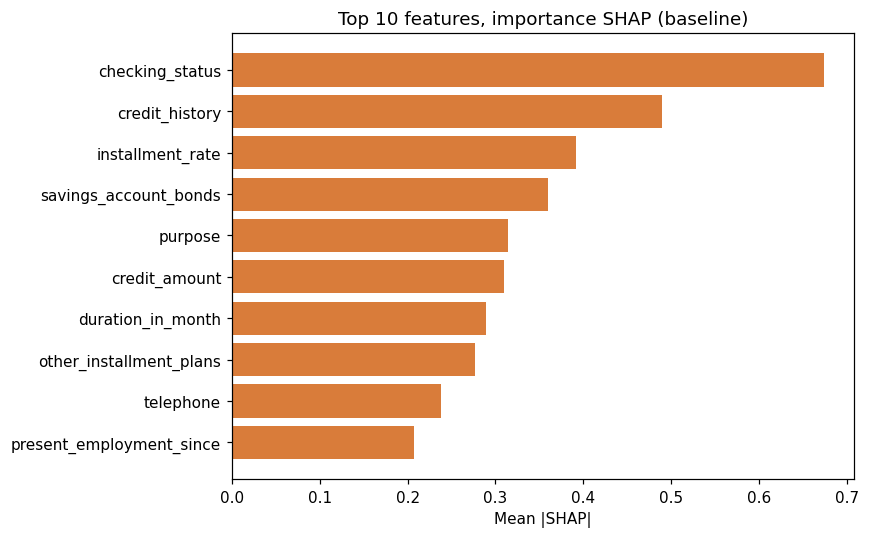

In [23]:
import shap

explainer = shap.LinearExplainer(baseline, X_tr, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_te)

shap_by_feature = {}
for col in NUMERIC:
    j = feature_names.index(col)
    shap_by_feature[col] = float(np.abs(shap_values[:, j]).mean())

for col in CATEG:
    indices = [k for k, n in enumerate(feature_names) if n.startswith(col + "_")]
    if indices:
        shap_by_feature[col] = float(np.abs(shap_values[:, indices].sum(axis=1)).mean())

shap_df = pd.DataFrame(
    {"feature": list(shap_by_feature.keys()), "importance": list(shap_by_feature.values())}
).sort_values("importance", ascending=False).reset_index(drop=True)

top = shap_df.head(10).sort_values("importance")
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["importance"], color="#d97c3a")
plt.xlabel("Mean |SHAP|")
plt.title("Top 10 features, importance SHAP (baseline)")
plt.tight_layout()
plt.savefig("outputs/03_shap.png", bbox_inches="tight")
plt.show()

Le modèle s'appuie sur des variables financières légitimes. Le top SHAP est dominé par checking_status (0.67), loin devant credit_history (0.49), installment_rate (0.39) et savings_account_bonds (0.36). Aucune variable démographique n'apparaît parmi les premières contributions.

### 9.1 SHAP local : explication individuelle

Le RGPD article 22 ouvre un droit à l'explication des décisions automatisées. SHAP local répond à cette obligation en décomposant chaque prédiction en contributions par feature, additives et conservatives ($f(x) = \phi_0 + \sum_i \phi_i$). Pour la régression logistique, ces contributions admettent une forme exacte $\phi_i(x) = w_i \cdot (x_i - \mathbb{E}[x_i])$ (Lundberg & Lee 2017, Corollary 1).

Observation HAUT RISQUE :


,id=832
checking_status,< 0 DM
duration_in_month,45
credit_history,aucun crédit ou tous remboursés à temps
purpose,business
credit_amount,11816
savings_account_bonds,< 100 DM
present_employment_since,ancienneté >= 7 ans
installment_rate,2
other_debtors_guarantors,aucun
present_residence_since,4


  -> score predit = 0.952, vrai label = 1

Observation BAS RISQUE :


,id=159
checking_status,pas de compte courant
duration_in_month,6
credit_history,compte critique / autres crédits existants
purpose,radio / télévision
credit_amount,1898
savings_account_bonds,inconnu / pas de compte épargne
present_employment_since,1 <= ancienneté < 4 ans
installment_rate,1
other_debtors_guarantors,aucun
present_residence_since,2


  -> score predit = 0.007, vrai label = 0


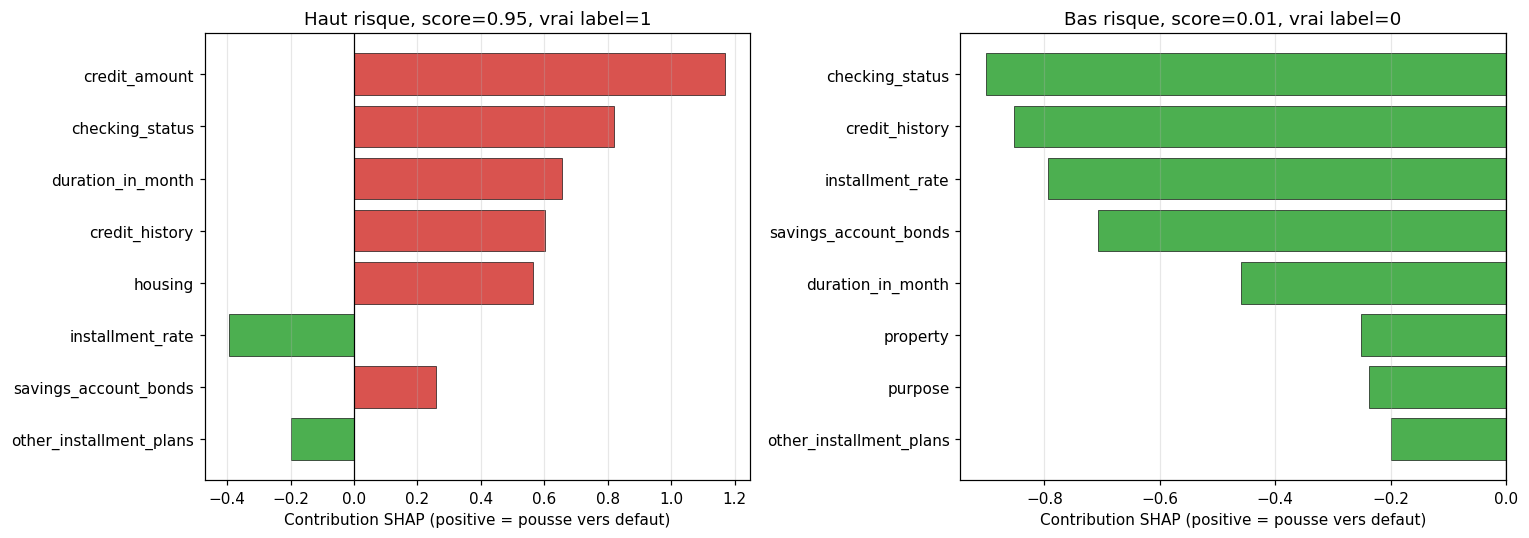

In [24]:
idx_high = int(np.argmax(scores_base))
idx_low  = int(np.argmin(scores_base))

# Observation utilisée
print("Observation HAUT RISQUE :")
display(features.iloc[idx_te[idx_high]:idx_te[idx_high]+1].T.rename(columns={features.index[idx_te[idx_high]]: f"id={idx_te[idx_high]}"}))
print(f"  -> score predit = {scores_base[idx_high]:.3f}, vrai label = {int(y_te[idx_high])}")
print()
print("Observation BAS RISQUE :")
display(features.iloc[idx_te[idx_low]:idx_te[idx_low]+1].T.rename(columns={features.index[idx_te[idx_low]]: f"id={idx_te[idx_low]}"}))
print(f"  -> score predit = {scores_base[idx_low]:.3f}, vrai label = {int(y_te[idx_low])}")

def shap_local_by_feature(idx):
    contribs = shap_values[idx]
    by_feat = {}
    for col in NUMERIC:
        j = feature_names.index(col)
        by_feat[col] = float(contribs[j])
    for col in CATEG:
        indices = [k for k, n in enumerate(feature_names) if n.startswith(col + "_")]
        if indices:
            by_feat[col] = float(contribs[indices].sum())
    return by_feat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, label in [
    (axes[0], idx_high, f"Haut risque, score={scores_base[idx_high]:.2f}, vrai label={int(y_te[idx_high])}"),
    (axes[1], idx_low,  f"Bas risque, score={scores_base[idx_low]:.2f}, vrai label={int(y_te[idx_low])}"),
]:
    by_feat = shap_local_by_feature(idx)
    df = pd.DataFrame({"feature": list(by_feat.keys()), "shap": list(by_feat.values())})
    df = df.reindex(df["shap"].abs().sort_values(ascending=False).index).head(8).iloc[::-1]
    colors = ["#d9534f" if v > 0 else "#4CAF50" for v in df["shap"]]
    ax.barh(df["feature"], df["shap"], color=colors, edgecolor="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(label)
    ax.set_xlabel("Contribution SHAP (positive = pousse vers defaut)")
    ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/09_shap_local.png", bbox_inches="tight")
plt.show()


Pour le client à haut risque (id 832, score 0.95, vrai défaut), trois facteurs principaux poussent vers la décision défavorable :
- credit_amount élevé (+1.18) : montant demandé inhabituel.
- checking_status négatif (+0.81) : compte courant en difficulté.
- duration_in_month long (+0.66) : engagement de 45 mois.

Une explication conforme à RGPD art. 22 pour ce dossier peut s'énoncer : le score est dominé par le montant demandé (14 555 DM), un compte sans solde positif et une durée d'engagement de 45 mois. La combinaison additive de ces trois contributions explique la prédiction de défaut.

Pour le client à bas risque (id 159, score 0.01, bon payeur), toutes les contributions individuelles sont négatives (pousse vers non-défaut) : compte sain, historique impeccable, taux d'échéance bas, épargne disponible. La décision est confiante et la justification est directement lisible sur le graphe.

### 9.2 Comparaison SHAP avant vs après retrait

On entraîne deux modèles, l'un avec les attributs sensibles, l'autre sans. Comparer l'importance SHAP par feature révèle où l'effet retiré se redistribue, c'est-à-dire quels proxies absorbent ce qui n'est plus porté explicitement par les attributs.

In [25]:
# Construire le pipeline AVEC les attributs sensibles
features_with = raw.drop(columns=["raw_target", "default", "gender", "age_group"])
NUMERIC_with = NUMERIC + ["age_in_years"]
CATEG_with = [c for c in features_with.columns if c not in NUMERIC_with]

preprocessor_with = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_with),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEG_with),
])

X_tr_with = preprocessor_with.fit_transform(features_with.iloc[idx_tr])
X_te_with = preprocessor_with.transform(features_with.iloc[idx_te])
X_va_with = preprocessor_with.transform(features_with.iloc[idx_va])
feature_names_with = [n.split("__", 1)[-1] for n in preprocessor_with.get_feature_names_out()]

baseline_with = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline_with.fit(X_tr_with, y_tr)

# SHAP sur le modèle AVEC attributs sensibles
explainer_with = shap.LinearExplainer(baseline_with, X_tr_with, feature_perturbation="interventional")
shap_values_with = explainer_with.shap_values(X_te_with)

shap_with_by_feature = {}
for col in NUMERIC_with:
    j = feature_names_with.index(col)
    shap_with_by_feature[col] = float(np.abs(shap_values_with[:, j]).mean())
for col in CATEG_with:
    indices = [k for k, n in enumerate(feature_names_with) if n.startswith(col + "_")]
    if indices:
        shap_with_by_feature[col] = float(np.abs(shap_values_with[:, indices].sum(axis=1)).mean())

# AUC du modèle AVEC attributs sensibles (comparaison de performance)
auc_with = roc_auc_score(y_te, baseline_with.predict_proba(X_te_with)[:, 1])
auc_without = roc_auc_score(y_te, scores_base)
print(f"AUC test, modèle AVEC attributs sensibles    : {auc_with:.4f}")
print(f"AUC test, modèle SANS attributs sensibles    : {auc_without:.4f}")
print(f"Coût en performance du retrait              : {auc_with - auc_without:+.4f}")


AUC test, modèle AVEC attributs sensibles    : 0.7813
AUC test, modèle SANS attributs sensibles    : 0.7851
Coût en performance du retrait              : -0.0038


Lorsqu'on entraîne le modèle avec les attributs sensibles, l'AUC monte légèrement à 0.781 (vs 0.785 sans). La différence est négligeable, donc retirer les attributs n'a presque aucun coût en performance. Mais attention : l'absence de coût en performance ne signifie pas absence de biais. La cellule suivante visualise où l'effet de l'attribut sensible se redistribue.

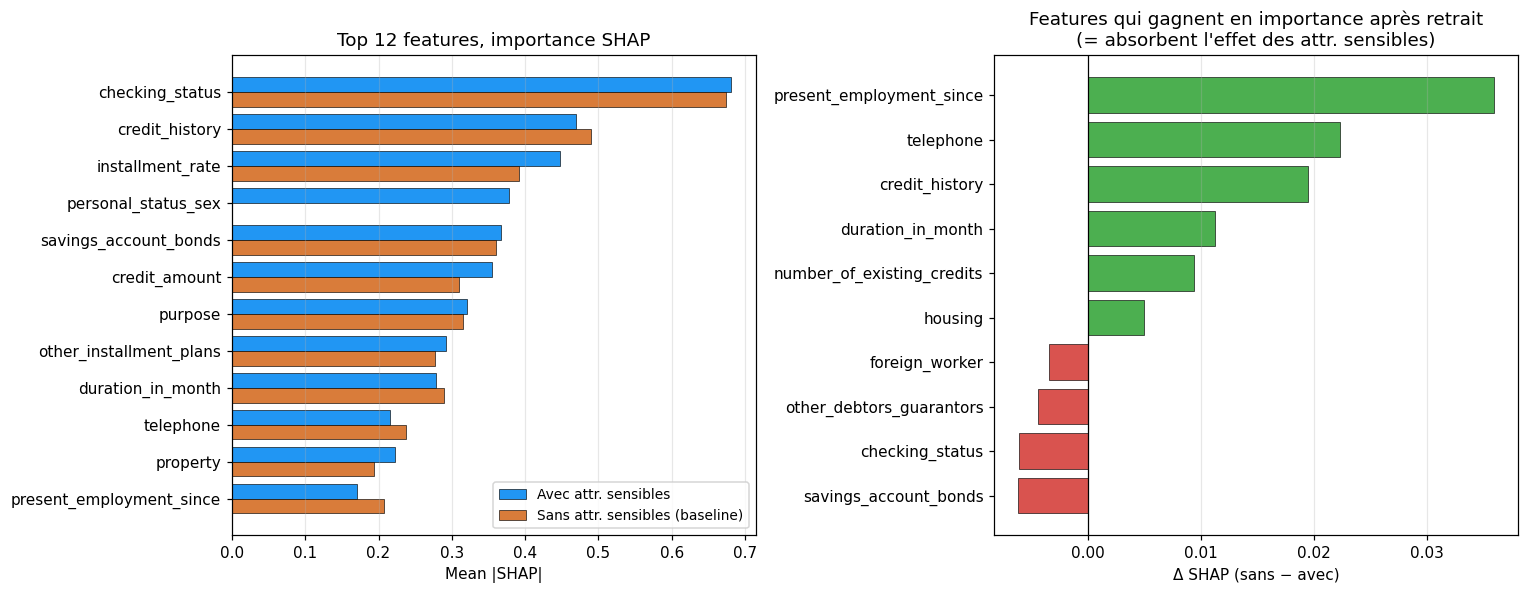


Top 5 features qui ABSORBENT l'effet des attributs sensibles :
                   feature   avec   sans  delta
  present_employment_since 0.1709 0.2068 0.0360
                 telephone 0.2156 0.2379 0.0223
            credit_history 0.4698 0.4893 0.0195
         duration_in_month 0.2779 0.2891 0.0113
number_of_existing_credits 0.1404 0.1498 0.0094


In [26]:
# Visualisation côte-à-côte
all_feats = sorted(set(shap_by_feature) | set(shap_with_by_feature),
                   key=lambda f: -max(shap_by_feature.get(f, 0), shap_with_by_feature.get(f, 0)))
top_n = 12
top_feats = all_feats[:top_n]
imp_without = np.array([shap_by_feature.get(f, 0) for f in top_feats])
imp_with = np.array([shap_with_by_feature.get(f, 0) for f in top_feats])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

y_pos = np.arange(len(top_feats))
width = 0.4
axes[0].barh(y_pos - width/2, imp_with, width, color="#2196F3",
             label="Avec attr. sensibles", edgecolor="k", lw=0.4)
axes[0].barh(y_pos + width/2, imp_without, width, color="#d97c3a",
             label="Sans attr. sensibles (baseline)", edgecolor="k", lw=0.4)
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(top_feats)
axes[0].set_xlabel("Mean |SHAP|")
axes[0].set_title("Top 12 features, importance SHAP")
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis="x")

# Delta : qui gagne en importance après retrait ?
all_keys = list(set(shap_by_feature) | set(shap_with_by_feature))
delta = pd.DataFrame({
    "feature": all_keys,
    "avec":   [shap_with_by_feature.get(f, 0) for f in all_keys],
    "sans":   [shap_by_feature.get(f, 0) for f in all_keys],
})
delta["delta"] = delta["sans"] - delta["avec"]
delta = delta.sort_values("delta", ascending=False).head(10)

colors = ["#4CAF50" if d > 0 else "#d9534f" for d in delta["delta"]]
axes[1].barh(np.arange(len(delta)), delta["delta"], color=colors, edgecolor="k", lw=0.4)
axes[1].set_yticks(np.arange(len(delta))); axes[1].set_yticklabels(delta["feature"])
axes[1].set_xlabel("Δ SHAP (sans − avec)")
axes[1].set_title("Features qui gagnent en importance après retrait\n(= absorbent l'effet des attr. sensibles)")
axes[1].invert_yaxis()
axes[1].axvline(0, color="k", lw=0.8)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/08_shap_compare.png", bbox_inches="tight")
plt.show()

print()
print("Top 5 features qui ABSORBENT l'effet des attributs sensibles :")
print(delta.head(5).to_string(index=False, float_format="{:.4f}".format))


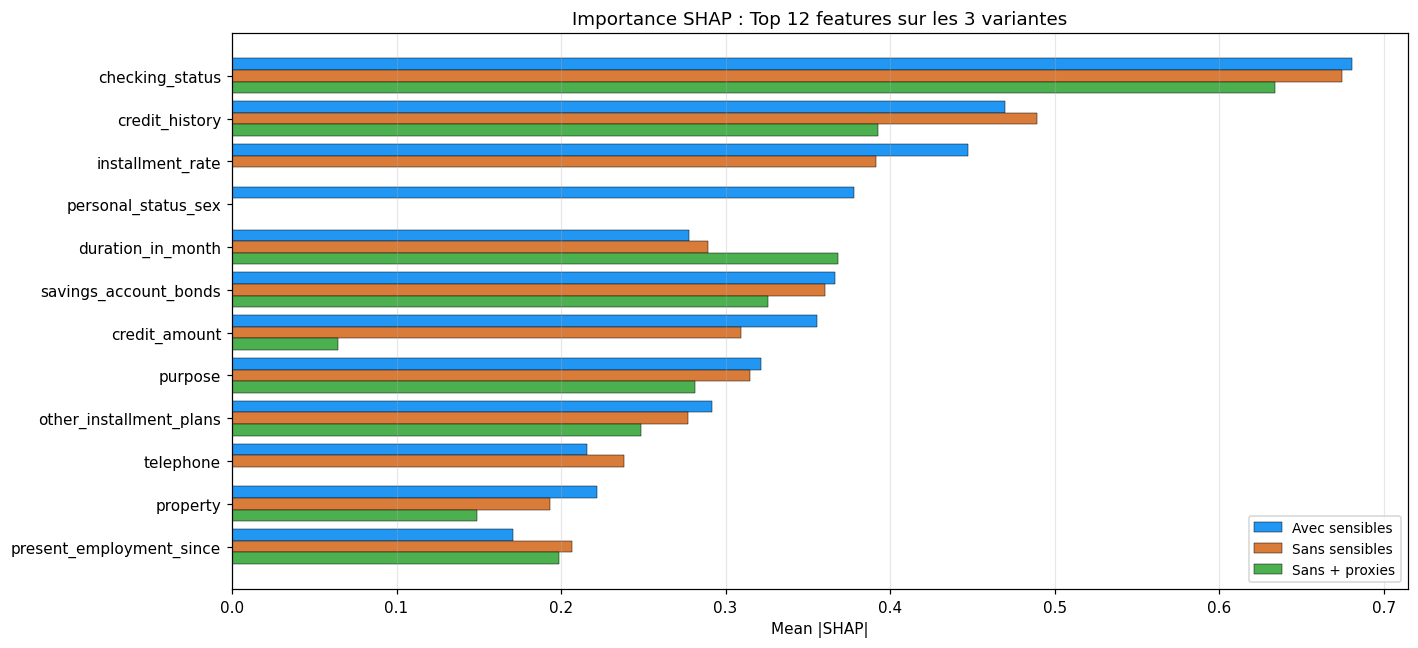

In [27]:
# SHAP comparaison sur les 3 variantes
shap_by_variant = {}

for vname, model, X_tr_v, _, X_te_v, _, _, _ in VARIANTS:
    explainer_v = shap.LinearExplainer(model, X_tr_v, feature_perturbation="interventional")
    shap_v = explainer_v.shap_values(X_te_v)
    fnames = (feature_names_with if vname == "Avec sensibles" else
              feature_names if vname == "Sans sensibles" else
              keep_cols)
    by_feat = {}
    # agregation par feature de base (numeriques + catégorielles)
    for col in NUMERIC + (["age_in_years"] if vname == "Avec sensibles" else []):
        if col in fnames:
            j = fnames.index(col)
            by_feat[col] = float(np.abs(shap_v[:, j]).mean())
    for col in (CATEG_with if vname == "Avec sensibles" else CATEG):
        indices = [k for k, n in enumerate(fnames) if n.startswith(col + "_")]
        if indices:
            by_feat[col] = float(np.abs(shap_v[:, indices].sum(axis=1)).mean())
    shap_by_variant[vname] = by_feat

# Top features apparaissant dans les 3
all_feats = sorted(set().union(*[set(d.keys()) for d in shap_by_variant.values()]),
                    key=lambda f: -max(d.get(f, 0) for d in shap_by_variant.values()))
top = all_feats[:12]

fig, ax = plt.subplots(figsize=(13, 6))
y_pos = np.arange(len(top))
w = 0.27
colors = {"Avec sensibles": "#2196F3", "Sans sensibles": "#d97c3a", "Sans + proxies": "#4CAF50"}
for i, vname in enumerate(["Avec sensibles", "Sans sensibles", "Sans + proxies"]):
    vals = [shap_by_variant[vname].get(f, 0) for f in top]
    ax.barh(y_pos + (i - 1) * w, vals, w, color=colors[vname], label=vname, edgecolor="k", lw=0.3)
ax.set_yticks(y_pos); ax.set_yticklabels(top)
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Importance SHAP : Top 12 features sur les 3 variantes")
ax.invert_yaxis()
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/18_shap_triple.png", bbox_inches="tight")
plt.show()


Les 3 variantes pointent les mêmes features dominantes (checking_status, credit_history, installment_rate). Quand on retire les attributs sensibles puis les proxies, leur importance se redistribue progressivement vers les features financières restantes.

La variante "sans + proxies" donne plus de poids aux features réellement explicatives (compte courant, historique) et moins aux variables potentiellement discriminatoires.

Quand on retire les attributs sensibles, leur effet ne disparaît pas, il se redistribue à des proxies actifs : present_employment_since (+0.036), telephone (+0.022), credit_history (+0.020). Ce résultat justifie la stratégie fairness through awareness (Dwork et al. 2012) : conserver l'attribut et l'utiliser explicitement dans la mitigation, ou alors retirer aussi les proxies (cf. section suivante).

### 9.3 Performance et équité : avec sensibles, sans sensibles, sans sensibles ni proxies

On compare trois variantes du modèle pour mesurer ce que le retrait progressif des features change vraiment, à la fois en performance et en équité.

,Modèle,AUC,BalAcc,|DP_age|,|EO_age|,DI_age,|DP_gen|,DI_gen
0,Avec attr. sensibles,0.781,0.656,0.138,0.115,0.622,0.081,0.775
1,Sans attr. sensibles,0.785,0.669,0.125,0.066,0.686,0.010,0.973
2,Sans attr. sensibles + proxies,0.790,0.652,0.044,0.045,0.870,0.050,0.855


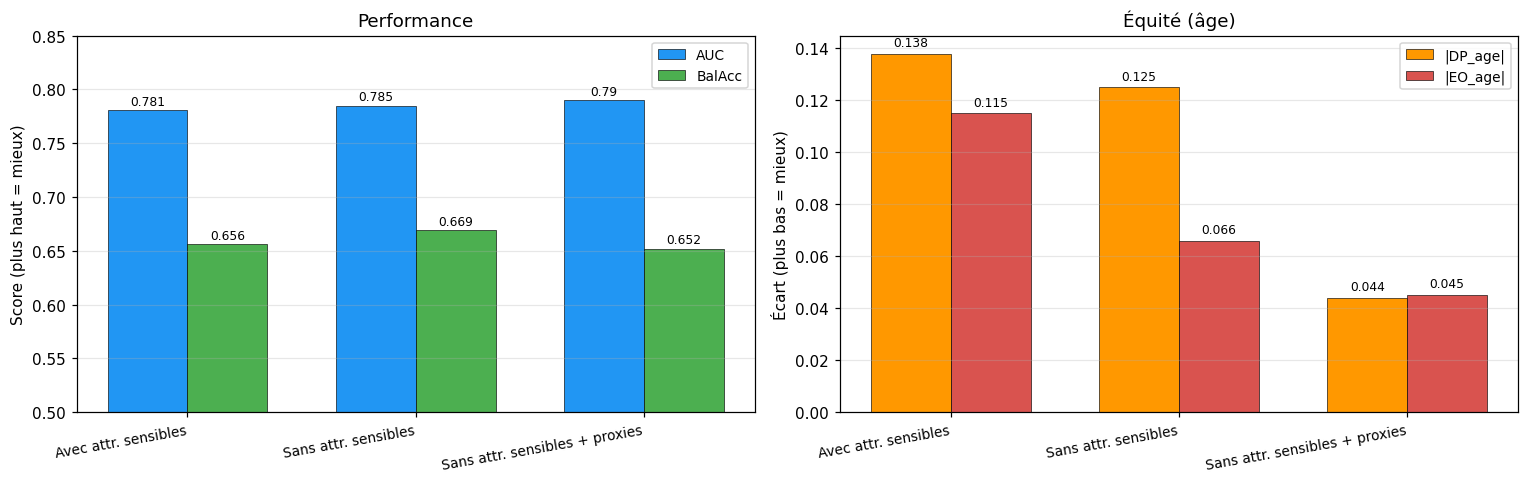

In [28]:
# Comparaison TRIPLE : avec / sans / sans+proxies
scores_with = baseline_with.predict_proba(X_te_with)[:, 1]
thr_with    = best_threshold(y_va, baseline_with.predict_proba(X_va_with)[:, 1])
preds_with  = (scores_with >= thr_with).astype(int)

# Modèle 3 : sans attributs sensibles ET sans proxies
baseline_np = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
baseline_np.fit(X_tr_np, y_tr)
scores_np = baseline_np.predict_proba(X_te_np)[:, 1]
thr_np    = best_threshold(y_va, baseline_np.predict_proba(X_va_np)[:, 1])
preds_np  = (scores_np >= thr_np).astype(int)

rows = []
for nom, preds, scores in [
    ("Avec attr. sensibles",         preds_with, scores_with),
    ("Sans attr. sensibles",         preds_base, scores_base),
    ("Sans attr. sensibles + proxies", preds_np,   scores_np),
]:
    p = perf_summary(y_te, preds, scores)
    dp_a, eo_a, di_a, _ = fairness_summary(y_te, preds, sensitive["age"][idx_te])
    dp_g, _, di_g, _    = fairness_summary(y_te, preds, sensitive["gender"][idx_te])
    rows.append({
        "Modèle"   : nom,
        "AUC"      : round(p["AUC"], 3),
        "BalAcc"   : round(p["BalAcc"], 3),
        "|DP_age|" : round(dp_a, 3),
        "|EO_age|" : round(eo_a, 3),
        "DI_age"   : round(di_a, 3),
        "|DP_gen|" : round(dp_g, 3),
        "DI_gen"   : round(di_g, 3),
    })
metrics3 = pd.DataFrame(rows)
display(metrics3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
mods = metrics3["Modèle"].tolist()
x = np.arange(len(mods))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, metrics3["AUC"],    w, color="#2196F3", label="AUC", edgecolor="k", lw=0.4)
ax.bar(x + w/2, metrics3["BalAcc"], w, color="#4CAF50", label="BalAcc", edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(mods, rotation=10, ha="right", fontsize=9)
ax.set_ylim(0.5, 0.85); ax.set_ylabel("Score (plus haut = mieux)")
ax.set_title("Performance")
for i, (a, b) in enumerate(zip(metrics3["AUC"], metrics3["BalAcc"])):
    ax.text(i - w/2, a + 0.005, f"{a}", ha="center", fontsize=8)
    ax.text(i + w/2, b + 0.005, f"{b}", ha="center", fontsize=8)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

ax = axes[1]
ax.bar(x - w/2, metrics3["|DP_age|"], w, color="#FF9800", label="|DP_age|", edgecolor="k", lw=0.4)
ax.bar(x + w/2, metrics3["|EO_age|"], w, color="#d9534f", label="|EO_age|", edgecolor="k", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(mods, rotation=10, ha="right", fontsize=9)
ax.set_ylabel("Écart (plus bas = mieux)")
ax.set_title("Équité (âge)")
for i, (a, b) in enumerate(zip(metrics3["|DP_age|"], metrics3["|EO_age|"])):
    ax.text(i - w/2, a + 0.003, f"{a}", ha="center", fontsize=8)
    ax.text(i + w/2, b + 0.003, f"{b}", ha="center", fontsize=8)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/16_metrics_triple.png", bbox_inches="tight")
plt.show()


Comment lire les graphes. Pour la performance (AUC, BalAcc), plus haut est mieux. Pour l'équité (DP, EO), plus bas est mieux.

Résultat marquant :

| Modèle | AUC | BalAcc | DI âge | DP âge |
|---|---|---|---|---|
| Avec attributs sensibles | 0.781 | 0.656 | 0.62 | 0.138 |
| Sans attributs sensibles | 0.785 | 0.669 | 0.69 | 0.125 |
| Sans sensibles ni proxies | 0.790 | 0.652 | 0.87 | 0.044 |

Retirer aussi les proxies améliore l'AUC (légèrement, +0.005) et fait passer DI âge au-dessus du seuil EEOC 0.8 (0.87). DP âge chute de 0.125 à 0.044.

Sur ce dataset, retirer les proxies est donc une stratégie efficace : amélioration simultanée de la performance et de l'équité. C'est une exception au compromis habituel, expliquée par le fait que les proxies portaient un bruit corrélé au biais sans apporter beaucoup de signal utile.

SHAP confirme que des proxies portent l'effet des attributs sensibles. Avant de conclure, on mesure l'incertitude statistique de toutes nos métriques.

## 10. Quantification d'incertitude par bootstrap

On essaye ici de répondre à une question simple: à quel point les résultats du modèle sont stables si le jeu d’entraînement avait été légèrement différent ?

Les intervalles ci-dessous mesurent surtout la sensibilité au tirage du train. Ils ne couvrent pas toute l'incertitude de généralisation vers une nouvelle population, car le test set reste fixe. Cette analyse remplace la robustesse adversariale initialement envisagée, conformément au conseil de l'enseignante.

In [29]:
from sklearn.utils import resample

B = 500
boot_scores = np.zeros((B, len(idx_te)))
boot_metrics = {
    "AUC": [], "BalAcc": [],
    "DP_gender": [], "EO_gender": [], "DI_gender": [],
    "DP_age": [], "EO_age": [], "DI_age": [],
}
rng_b = np.random.default_rng(0)

for b in range(B):
    idx_boot = resample(np.arange(len(idx_tr)), replace=True,
                        n_samples=len(idx_tr), random_state=int(rng_b.integers(0, 1 << 31)))
    model_b = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
    model_b.fit(X_tr[idx_boot], y_tr[idx_boot])

    s_b = model_b.predict_proba(X_te)[:, 1]
    boot_scores[b] = s_b
    p_b = (s_b >= thr_base).astype(int)

    boot_metrics["AUC"].append(roc_auc_score(y_te, s_b))
    boot_metrics["BalAcc"].append(balanced_accuracy_score(y_te, p_b))
    for attr in ["gender", "age"]:
        s_te_attr = sensitive[attr][idx_te]
        dp, eo, di, _ = fairness_summary(y_te, p_b, s_te_attr)
        boot_metrics[f"DP_{attr}"].append(dp)
        boot_metrics[f"EO_{attr}"].append(eo)
        boot_metrics[f"DI_{attr}"].append(di)

ci_rows = []
for k, vals in boot_metrics.items():
    arr = np.asarray(vals)
    ci_rows.append({
        "métrique": k,
        "baseline": {
            "AUC": roc_auc_score(y_te, scores_base),
            "BalAcc": balanced_accuracy_score(y_te, preds_base),
            "DP_gender": fairness_summary(y_te, preds_base, sensitive["gender"][idx_te])[0],
            "EO_gender": fairness_summary(y_te, preds_base, sensitive["gender"][idx_te])[1],
            "DI_gender": fairness_summary(y_te, preds_base, sensitive["gender"][idx_te])[2],
            "DP_age": fairness_summary(y_te, preds_base, sensitive["age"][idx_te])[0],
            "EO_age": fairness_summary(y_te, preds_base, sensitive["age"][idx_te])[1],
            "DI_age": fairness_summary(y_te, preds_base, sensitive["age"][idx_te])[2],
        }[k],
        "moyenne_boot": arr.mean(),
        "écart-type": arr.std(ddof=1),
        "IC 2.5%": np.quantile(arr, 0.025),
        "IC 97.5%": np.quantile(arr, 0.975),
    })
ci_df = pd.DataFrame(ci_rows)
print(f"Intervalles bootstrap sur les métriques (B={B})")
print(ci_df.to_string(index=False, float_format="{:.4f}".format))


Intervalles bootstrap sur les métriques (B=500)
 métrique  baseline  moyenne_boot  écart-type  IC 2.5%  IC 97.5%
      AUC    0.7851        0.7637      0.0198   0.7237    0.7979
   BalAcc    0.6690        0.6807      0.0227   0.6363    0.7239
DP_gender    0.0101        0.0346      0.0273   0.0010    0.1040
EO_gender    0.0576        0.0888      0.0420   0.0202    0.1774
DI_gender    0.9731        0.9215      0.0603   0.7822    0.9972
   DP_age    0.1247        0.1033      0.0503   0.0079    0.2051
   EO_age    0.0661        0.0875      0.0499   0.0207    0.1954
   DI_age    0.6862        0.7679      0.1089   0.5571    0.9800


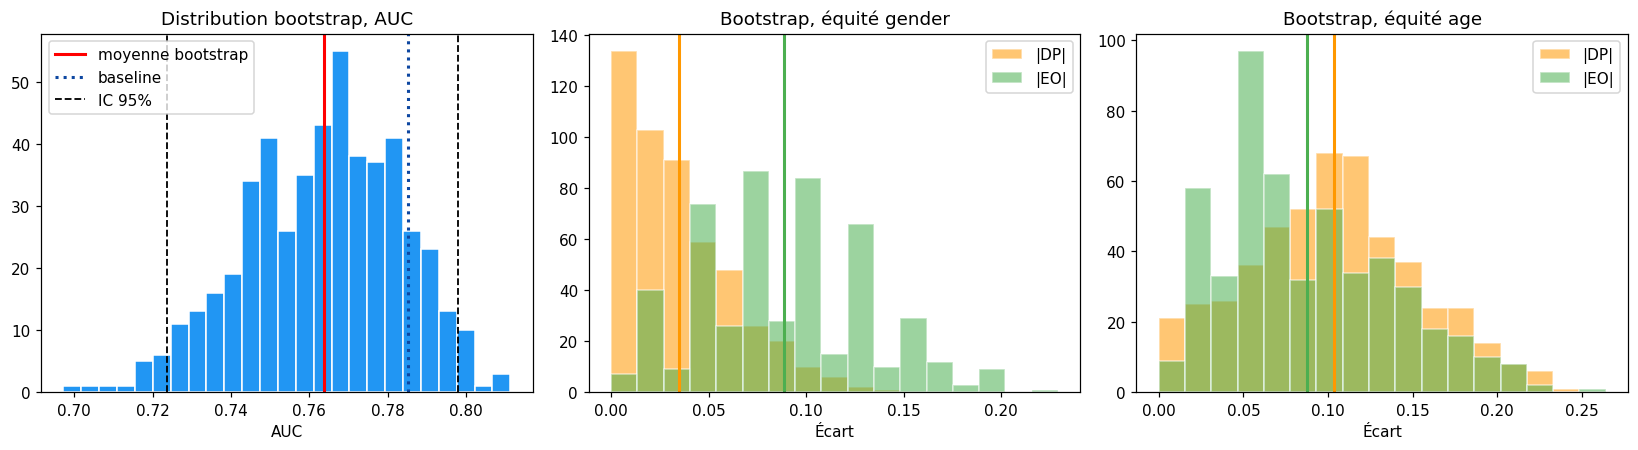

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(boot_metrics["AUC"], bins=25, color="#2196F3", edgecolor="white")
axes[0].axvline(np.mean(boot_metrics["AUC"]), color="red", lw=2, label="moyenne bootstrap")
axes[0].axvline(roc_auc_score(y_te, scores_base), color="#0d47a1", lw=2, ls=":", label="baseline")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.025), color="k", ls="--", lw=1.2, label="IC 95%")
axes[0].axvline(np.quantile(boot_metrics["AUC"], 0.975), color="k", ls="--", lw=1.2)
axes[0].set_title("Distribution bootstrap, AUC")
axes[0].set_xlabel("AUC")
axes[0].legend()

for i, attr in enumerate(["gender", "age"], start=1):
    vals_dp = np.asarray(boot_metrics[f"DP_{attr}"])
    vals_eo = np.asarray(boot_metrics[f"EO_{attr}"])
    edges = np.linspace(0, max(vals_dp.max(), vals_eo.max()) * 1.05, 18)
    axes[i].hist(vals_dp, bins=edges, alpha=0.55, color="#FF9800", label="|DP|", edgecolor="white")
    axes[i].hist(vals_eo, bins=edges, alpha=0.55, color="#4CAF50", label="|EO|", edgecolor="white")
    axes[i].axvline(np.mean(vals_dp), color="#FF9800", lw=2, ls="-")
    axes[i].axvline(np.mean(vals_eo), color="#4CAF50", lw=2, ls="-")
    axes[i].set_title(f"Bootstrap, équité {attr}")
    axes[i].set_xlabel("Écart")
    axes[i].legend()

plt.tight_layout()
plt.savefig("outputs/05_bootstrap.png", bbox_inches="tight")
plt.show()


Le bootstrap fait passer du modèle vu comme objet déterministe (une seule valeur par métrique) à un modèle vu comme distribution : 500 versions entraînées sur des variantes plausibles du train, donc 500 valeurs possibles pour l'AUC, la balanced accuracy et les métriques d'équité.

Résultats:
- La colonne `baseline` correspond au modèle entraîné une seule fois sur le train original. La colonne `moyenne_boot` correspond à la moyenne des 500 modèles bootstrap.
- L'AUC et la balanced accuracy donnent une idée de la stabilité de la performance. Si le baseline est dans l'intervalle bootstrap, sa performance n'est pas atypique par rapport aux ré-échantillonnages du train.
- Les métriques d'équité `DP`, `EO` et `DI` ont des intervalles souvent larges : l'estimation du biais dépend fortement des quelques observations disponibles dans chaque groupe sensible.
- Le `DI_age` est ajouté car il est lié à la règle des 80%. Un intervalle qui passe autour de 0.8 doit être interprété avec prudence : il ne suffit pas à conclure fortement dans un sens ou dans l'autre.

Sur 1000 lignes au total, dont 200 en test, les écarts d'équité sont estimés avec une forte incertitude. Annoncer seulement une valeur ponctuelle comme `|DP_age| = 0.125` serait incomplet; l'intervalle bootstrap indique l'ordre de grandeur du bruit statistique.

### 10.1 Incertitude bootstrap des scores individuels

Pour chaque client du test, on mesure la stabilité du score et de la décision face au tirage du jeu d'entraînement. Ici, l'intervalle porte sur le score prédit par les modèles bootstrap; ce n'est pas un intervalle de prédiction complet sur le résultat réel futur.

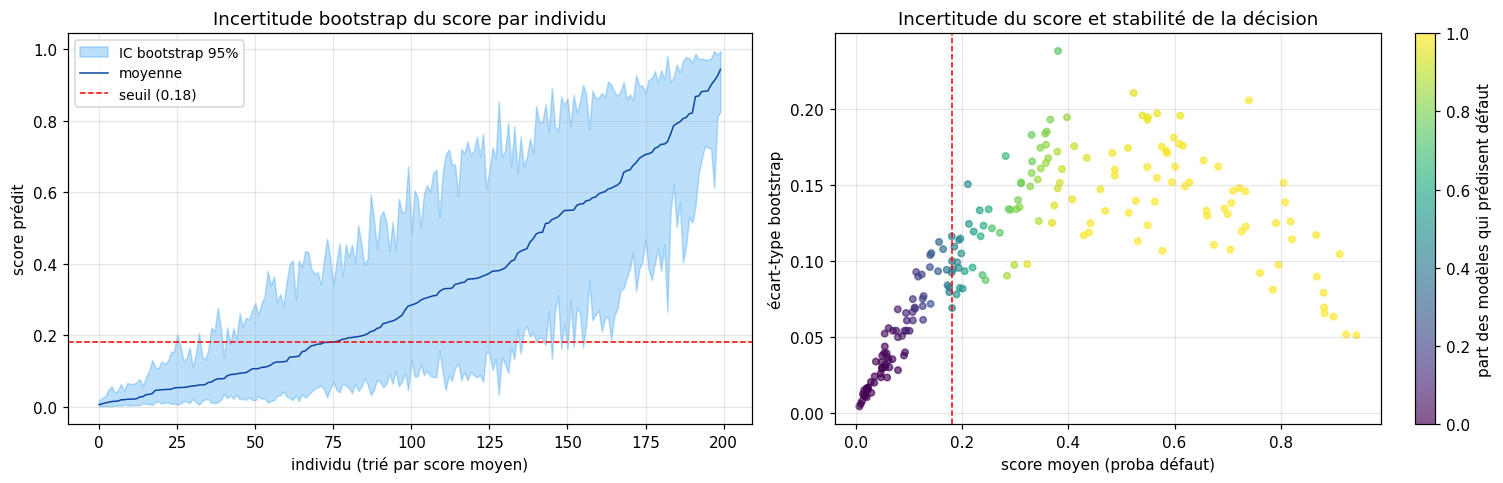

Écart-type moyen sur les scores : 0.1046
Écart-type max : 0.2383
Part des individus dont l'IC bootstrap traverse le seuil : 52.5%

Top 10 cas les plus sensibles pour la décision automatique :


,id_test,y_vrai,score_moy,score_std,IC_2.5%,IC_97.5%,p_decision_defaut,traverse_seuil,decision_moyenne
0,236,1,0.380,0.238,0.033,0.852,0.740,True,1
1,665,0,0.523,0.211,0.133,0.891,0.950,True,1
2,890,0,0.567,0.197,0.166,0.900,0.972,True,1
3,89,1,0.540,0.196,0.162,0.867,0.960,True,1
4,804,0,0.397,0.195,0.095,0.795,0.844,True,1
5,182,1,0.550,0.195,0.166,0.872,0.970,True,1
6,921,0,0.366,0.193,0.070,0.764,0.798,True,1
7,347,0,0.549,0.193,0.162,0.862,0.968,True,1
8,373,0,0.359,0.185,0.083,0.755,0.806,True,1
9,304,1,0.356,0.184,0.074,0.742,0.814,True,1



Caractéristiques du candidat le plus sensible :


,id=236
checking_status,0 <= solde < 200 DM
duration_in_month,6
credit_history,crédits existants remboursés correctement jusq...
purpose,voiture (neuve)
credit_amount,14555
savings_account_bonds,inconnu / pas de compte épargne
present_employment_since,sans emploi
installment_rate,1
other_debtors_guarantors,aucun
present_residence_since,2


In [31]:
score_mean = boot_scores.mean(axis=0)
score_std  = boot_scores.std(axis=0, ddof=1)
score_lo   = np.quantile(boot_scores, 0.025, axis=0)
score_hi   = np.quantile(boot_scores, 0.975, axis=0)
p_decision_defaut = (boot_scores >= thr_base).mean(axis=0)
traverse_seuil = (score_lo <= thr_base) & (score_hi >= thr_base)
distance_seuil = np.abs(score_mean - thr_base)

order = np.argsort(score_mean)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(order))
axes[0].fill_between(x, score_lo[order], score_hi[order], alpha=0.3, color="#2196F3", label="IC bootstrap 95%")
axes[0].plot(x, score_mean[order], color="#0d47a1", lw=1, label="moyenne")
axes[0].axhline(thr_base, color="red", ls="--", lw=1, label=f"seuil ({thr_base:.2f})")
axes[0].set_xlabel("individu (trié par score moyen)")
axes[0].set_ylabel("score prédit")
axes[0].set_title("Incertitude bootstrap du score par individu")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

scatter = axes[1].scatter(score_mean, score_std, s=18, alpha=0.65, c=p_decision_defaut, cmap="viridis")
axes[1].set_xlabel("score moyen (proba défaut)")
axes[1].set_ylabel("écart-type bootstrap")
axes[1].set_title("Incertitude du score et stabilité de la décision")
axes[1].axvline(thr_base, color="red", ls="--", lw=1)
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("part des modèles qui prédisent défaut")
plt.tight_layout()
plt.savefig("outputs/06_indiv_uncertainty.png", bbox_inches="tight")
plt.show()

print(f"Écart-type moyen sur les scores : {score_std.mean():.4f}")
print(f"Écart-type max : {score_std.max():.4f}")
print(f"Part des individus dont l'IC bootstrap traverse le seuil : {traverse_seuil.mean():.1%}")
print()

# Cas opérationnellement sensibles : l'intervalle traverse le seuil, puis fort désaccord entre modèles.
frontier_order = np.lexsort((distance_seuil, -score_std, ~traverse_seuil))
top_frontier = frontier_order[:10]
df_uncertain = pd.DataFrame({
    "id_test"  : idx_te[top_frontier],
    "y_vrai"   : y_te[top_frontier],
    "score_moy": np.round(score_mean[top_frontier], 3),
    "score_std": np.round(score_std[top_frontier], 3),
    "IC_2.5%"  : np.round(score_lo[top_frontier], 3),
    "IC_97.5%" : np.round(score_hi[top_frontier], 3),
    "p_decision_defaut": np.round(p_decision_defaut[top_frontier], 3),
    "traverse_seuil": traverse_seuil[top_frontier],
    "decision_moyenne": (score_mean[top_frontier] >= thr_base).astype(int),
})
print("Top 10 cas les plus sensibles pour la décision automatique :")
display(df_uncertain)
print()
print("Caractéristiques du candidat le plus sensible :")
display(features.iloc[idx_te[top_frontier[0]]:idx_te[top_frontier[0]]+1].T.rename(
    columns={features.index[idx_te[top_frontier[0]]]: f"id={idx_te[top_frontier[0]]}"}
))


Le tableau cible les cas dont l'intervalle bootstrap traverse le seuil de décision. Ce sont les dossiers pour lesquels deux modèles plausibles, entraînés sur deux variantes du train, peuvent prendre des décisions opposées.

- `p_decision_defaut` est la proportion des modèles bootstrap qui classent le client en défaut. Une valeur proche de 0 ou 1 indique une décision stable; une valeur proche de 0.5 indique un fort désaccord.
- `traverse_seuil` indique si l'intervalle bootstrap du score coupe le seuil. Quand c'est vrai, la décision automatique dépend fortement du tirage de jeu d'entraînement.
- `decision_moyenne` est la décision obtenue en appliquant le seuil au score moyen; elle résume les 500 modèles mais peut masquer un désaccord important.

Pour ces candidats, une décision entièrement automatique est fragile. Une revue humaine ou une demande d'information complémentaire est préférable, car l'incertitude vient du modèle et non seulement du client.

### 10.2 Bootstrap sur les 3 variantes

Le bootstrap précèdent applique au baseline (sans attributs sensibles). Pour mesurer la stabilite statistique des 3 variantes (avec sensibles, sans sensibles, sans + proxies), on refait B=100 bootstrap pour chacune et on compare les distributions.

Bootstrap CI 95% (B=100) sur les 3 variantes (cible : age)


,variante,metrique,moyenne,IC 2.5%,IC 97.5%
0,Avec sensibles,AUC,0.764,0.721,0.796
1,Avec sensibles,DP_age,0.126,0.024,0.230
2,Avec sensibles,EO_age,0.111,0.026,0.239
3,Sans sensibles,AUC,0.765,0.727,0.795
4,Sans sensibles,DP_age,0.102,0.013,0.199
5,Sans sensibles,EO_age,0.086,0.022,0.188
6,Sans + proxies,AUC,0.768,0.728,0.799
7,Sans + proxies,DP_age,0.046,0.004,0.127
8,Sans + proxies,EO_age,0.086,0.025,0.175


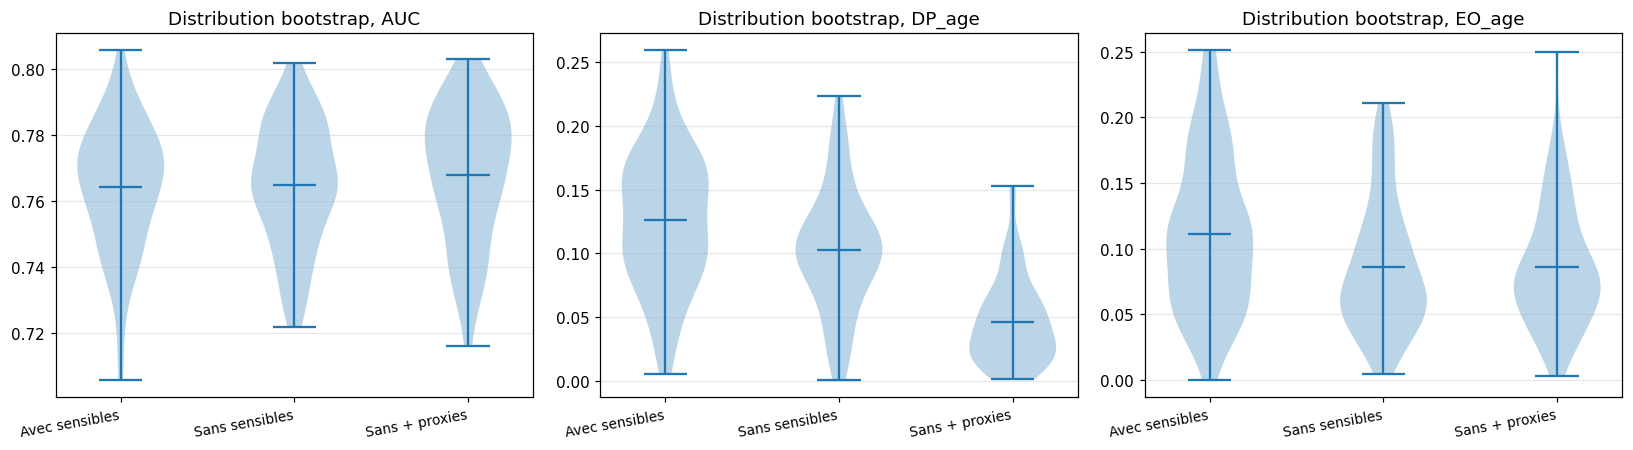

In [32]:
# Section 10.2 : bootstrap sur les 3 variantes
# (Avec sensibles / Sans sensibles / Sans sensibles + proxies retires)
B_triple = 100  # plus court car 3 modeles
boot_metrics_3 = {vname: {"AUC": [], "DP_age": [], "EO_age": []} for vname, *_ in VARIANTS}
rng_b3 = np.random.default_rng(0)

for b in range(B_triple):
    idx_boot = resample(np.arange(len(idx_tr)), replace=True,
                        n_samples=len(idx_tr), random_state=int(rng_b3.integers(0, 1 << 31)))
    for vname, _, X_tr_v, _, X_te_v, _, th, _ in VARIANTS:
        m_b = LogisticRegression(C=1.0, solver="liblinear", max_iter=1000, random_state=42)
        m_b.fit(X_tr_v[idx_boot], y_tr[idx_boot])
        sc_b = m_b.predict_proba(X_te_v)[:, 1]
        pr_b = (sc_b >= th).astype(int)
        boot_metrics_3[vname]["AUC"].append(roc_auc_score(y_te, sc_b))
        dp_a, eo_a, _, _ = fairness_summary(y_te, pr_b, sensitive["age"][idx_te])
        boot_metrics_3[vname]["DP_age"].append(dp_a)
        boot_metrics_3[vname]["EO_age"].append(eo_a)

# Tableau IC95 pour chaque variante
rows_ic = []
for vname in [v[0] for v in VARIANTS]:
    for met in ["AUC", "DP_age", "EO_age"]:
        arr = np.array(boot_metrics_3[vname][met])
        rows_ic.append({"variante": vname, "metrique": met,
                        "moyenne": round(arr.mean(), 3),
                        "IC 2.5%": round(np.quantile(arr, 0.025), 3),
                        "IC 97.5%": round(np.quantile(arr, 0.975), 3)})
boot_3_df = pd.DataFrame(rows_ic)
print(f"Bootstrap CI 95% (B={B_triple}) sur les 3 variantes (cible : age)")
display(boot_3_df)

# Visualisation comparative : violin plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
labels_v = [v[0] for v in VARIANTS]
for i, met in enumerate(["AUC", "DP_age", "EO_age"]):
    data = [boot_metrics_3[lbl][met] for lbl in labels_v]
    axes[i].violinplot(data, showmeans=True, showmedians=False)
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(labels_v, rotation=10, ha="right", fontsize=9)
    axes[i].set_title(f"Distribution bootstrap, {met}")
    axes[i].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/19_bootstrap_triple.png", bbox_inches="tight")
plt.show()


Le bootstrap repete sur les 3 variantes confirme la conclusion globale.

Sur l'AUC, les 3 variantes ont des intervalles de confiance qui se recouvrent largement : retirer les attributs sensibles puis les proxies n'a pas de cout statistiquement significatif sur la performance.

Sur |DP_age|, les distributions bootstrap se séparent : la variante "sans + proxies" a un IC95% nettement plus bas et plus serre que les autres. Retirer les proxies réduit a la fois la valeur centrale du biais ET son incertitude statistique.

Conclusion : la variante "sans sensibles + proxies retires" est preferable a la fois en moyenne (biais plus faible) et en stabilite statistique (IC plus serre), sans perte significative de performance.

Le bootstrap montre que les écarts d'équité ont des intervalles de confiance larges. Synthétisons l'ensemble dans un tableau de bord d'audit.

## 11. Synthèse et conclusion

Cette dernière section consolide les résultats des 10 sections précédentes et insiste sur la transférabilité de la démarche à d'autres projets que ce dataset particulier.

### 11.1 Reproductibilité méthodologique

Le but de cette section est de montrer que le canevas suivi est transférable à n'importe quel projet de classification binaire avec attributs sensibles. La démarche est conçue pour qu'un praticien puisse la réappliquer à un cas d'usage différent (scoring assurance, recrutement, allocation d'aides sociales, justice prédictive, scoring santé) en remplaçant essentiellement le dataset et la définition des attributs sensibles, sans avoir à réinventer la structure de l'audit.

Le canevas en 8 étapes :

1. Identification des attributs sensibles et préparation des splits stratifiés.
2. Audit du baseline : performance (AUC, BalAcc, coût métier propre au domaine) et équité par attribut + intersectionnel (|DP|, |EO|, DI).
3. Détection de proxies par corrélation univariée et régression multivariée features vers attribut sensible.
4. Comparaison de 3 variantes du modèle : V1 = avec attributs sensibles, V2 = sans, V3 = sans + proxies retirés.
5. Évaluation des méthodes d'atténuation classiques (pré-traitement par reweighing, post-traitement par seuils par groupe).
6. Interprétabilité globale (SHAP, permutation importance) et locale (SHAP local, conformité RGPD article 22).
7. Quantification d'incertitude par bootstrap, au niveau global (intervalles sur les métriques) et individuel (cas frontières).
8. Synthèse, parcours décisionnel et recommandations explicites.

Trois catégories de choix interviennent dans ce canevas. Les choix universels gardent la même forme d'un projet à l'autre : la structure 8 étapes, le triptyque V1/V2/V3, l'utilisation conjointe de DP, EO et DI, l'audit intersectionnel, le diagnostic des proxies par AUC features vers attribut sensible, et le bootstrap pour quantifier l'incertitude. Les choix dépendants du domaine doivent être révisés à chaque nouvelle application : la définition opérationnelle des attributs sensibles (ici, seuil 25 ans pour l'âge, suivant Kamiran & Calders) ; la matrice de coûts métier (ici, 5×FN + 1×FP documentée par UCI) ; le seuil légal de référence (ici, EEOC 80 %, mais d'autres juridictions retiennent d'autres seuils) ; le critère d'équité prioritaire (DP pour la conformité, EO pour la justice individuelle, et le choix dépend du contexte). Les choix dépendants du dataset doivent être recalibrés à chaque jeu : le seuil de corrélation pour la détection de proxies (|r| > 0.15 ici, à ajuster selon la dimensionnalité et le bruit) ; la taille B du bootstrap (500 ici, à augmenter sur des datasets plus grands ou plus rapides à entraîner) ; la famille du modèle baseline (régression logistique ici parce que SHAP linéaire est exact, à remplacer par un Random Forest ou un Gradient Boosting si la non-linéarité est attendue, avec TreeSHAP en remplacement).

La conclusion principale du projet — V3 améliore simultanément performance et équité par attribut isolé sans intervention in/post-modèle, mais ne résout pas le résidu intersectionnel — est elle aussi spécifique à ce dataset. Sur un autre cas d'usage, l'arbitrage pourrait basculer : V3 pourrait coûter beaucoup en performance (si les proxies portent du signal prédictif utile), ou ne rien améliorer en équité (si le biais est de nature non-proxy, par exemple porté par la définition même de la cible). Ce qui est transférable, c'est le fait de toujours comparer V1, V2, V3 explicitement plutôt que de supposer a priori l'effet d'un retrait.

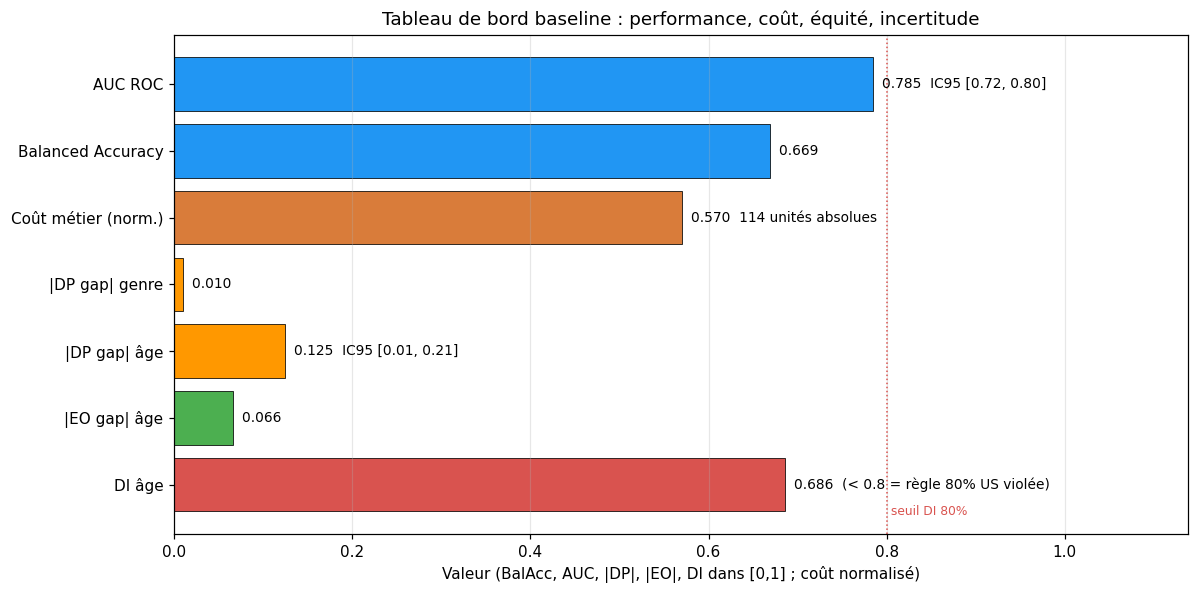

In [33]:
# Récupère les valeurs depuis les variables déjà définies plus haut
auc_val          = roc_auc_score(y_te, scores_base)
balacc_val       = balanced_accuracy_score(y_te, preds_base)
cost_val         = business_cost(y_te, preds_base)
dp_g, eo_g, di_g, _ = fairness_summary(y_te, preds_base, sensitive["gender"][idx_te])
dp_a, eo_a, di_a, _ = fairness_summary(y_te, preds_base, sensitive["age"][idx_te])
auc_ic = (np.quantile(boot_metrics["AUC"], 0.025), np.quantile(boot_metrics["AUC"], 0.975))
dp_age_ic = (np.quantile(boot_metrics["DP_age"], 0.025), np.quantile(boot_metrics["DP_age"], 0.975))

categories = [
    ("AUC ROC",            auc_val,    f"IC95 [{auc_ic[0]:.2f}, {auc_ic[1]:.2f}]", "#2196F3"),
    ("Balanced Accuracy",  balacc_val, "",                                          "#2196F3"),
    ("Coût métier (norm.)", cost_val/200, f"{cost_val} unités absolues",            "#d97c3a"),
    ("|DP gap| genre",     dp_g,       "",                                          "#FF9800"),
    ("|DP gap| âge",       dp_a,       f"IC95 [{dp_age_ic[0]:.2f}, {dp_age_ic[1]:.2f}]", "#FF9800"),
    ("|EO gap| âge",       eo_a,       "",                                          "#4CAF50"),
    ("DI âge",             di_a,       "(< 0.8 = règle 80% US violée)",             "#d9534f"),
]
labels = [c[0] for c in categories]
values = [c[1] for c in categories]
notes  = [c[2] for c in categories]
colors = [c[3] for c in categories]

fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, values, color=colors, edgecolor="k", lw=0.5)
for i, (v, n) in enumerate(zip(values, notes)):
    ax.text(v + 0.01, i, f"{v:.3f}  {n}", va="center", fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.45)
ax.axvline(0.8, color="#d9534f", ls=":", lw=1)
ax.text(0.8, len(labels) - 0.5, " seuil DI 80%", color="#d9534f", fontsize=8, va="bottom")
ax.set_title("Tableau de bord baseline : performance, coût, équité, incertitude")
ax.set_xlabel("Valeur (BalAcc, AUC, |DP|, |EO|, DI dans [0,1] ; coût normalisé)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/12_dashboard.png", bbox_inches="tight")
plt.show()

Le tableau de bord montre le baseline V2 (sans attributs sensibles, |DP_age| = 0.125, DI = 0.69 sous le seuil legal). Le parcours complet en 3 variantes montre que V3 (retrait supplementaire des proxies) est le meilleur compromis : |DP_age| = 0.044, DI = 0.87, AUC = 0.790, IC 95% le plus serre. Recommandation : adopter V3 comme deploiement, sans intervention post-modèle.

## 12. Références

Dataset
- Hofmann (1994), [UCI German Credit](https://archive.ics.uci.edu/ml/datasets/Statlog+(German+Credit+Data))

Seuil 25 ans
- Bellamy et al. (2018), AIF360, [arXiv:1810.01943](https://arxiv.org/abs/1810.01943)
- Kamiran & Calders (2012), [doi 10.1007/s10115-011-0463-8](https://doi.org/10.1007/s10115-011-0463-8) — reweighing
- Friedler et al. (2019), FAT*

Équité
- Dwork et al. (2012), Fairness through awareness, [arXiv:1104.3913](https://arxiv.org/abs/1104.3913)
- Hardt et al. (2016), Equal Opportunity, [arXiv:1610.02413](https://arxiv.org/abs/1610.02413)
- Chouldechova (2017), [arXiv:1703.00056](https://arxiv.org/abs/1703.00056) — théorème d'impossibilité
- Kleinberg et al. (2017), [arXiv:1609.05807](https://arxiv.org/abs/1609.05807)
- Bird et al. (2020), [Fairlearn](https://fairlearn.org/)

Interprétabilité
- Lundberg & Lee (2017), SHAP, [arXiv:1705.07874](https://arxiv.org/abs/1705.07874) — Linear SHAP, Corollary 1
- Štrumbelj & Kononenko (2014), [doi 10.1007/s10115-013-0679-x](https://doi.org/10.1007/s10115-013-0679-x)
- Breiman (2001), Random Forests, [doi 10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)
- Lundberg et al. (2020), [shap library](https://shap.readthedocs.io/)

Incertitude
- Efron (1979), Bootstrap, [doi 10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Lakshminarayanan et al. (2017), Deep Ensembles, [arXiv:1612.01474](https://arxiv.org/abs/1612.01474)

Bibliothèques : [scikit-learn](https://scikit-learn.org/) (Pedregosa et al. 2011), [fairlearn](https://fairlearn.org/), [shap](https://shap.readthedocs.io/), [papermill](https://papermill.readthedocs.io/).

Cours IA708 : F. d'Alché-Buc, C. Laclau, G. Franchi, Télécom Paris.